<a href="https://colab.research.google.com/github/Madhanshashank/final_project/blob/Data-projects/Customer_prediction_madhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#DATA LOADING AND PREPROCESSING

In [ ]:
dataset = pd.read_csv('train.csv')

In [ ]:
print(dataset.shape)
dataset.head()

(45211, 11)


,age,job,marital,education_qual,call_type,day,mon,dur,num_calls,prev_outcome,y
0,58,management,married,tertiary,unknown,5,may,261,1,unknown,no
1,44,technician,single,secondary,unknown,5,may,151,1,unknown,no
2,33,entrepreneur,married,secondary,unknown,5,may,76,1,unknown,no
3,47,blue-collar,married,unknown,unknown,5,may,92,1,unknown,no
4,33,unknown,single,unknown,unknown,5,may,198,1,unknown,no


In [ ]:
dataset.describe()

,age,day,dur,num_calls
count,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,15.806419,258.163080,2.763841
std,10.618762,8.322476,257.527812,3.098021
min,18.000000,1.000000,0.000000,1.000000
25%,33.000000,8.000000,103.000000,1.000000
50%,39.000000,16.000000,180.000000,2.000000
75%,48.000000,21.000000,319.000000,3.000000
max,95.000000,31.000000,4918.000000,63.000000


In [ ]:
dataset.isnull().sum()

,0
age,0
job,0
marital,0
education_qual,0
call_type,0
day,0
mon,0
dur,0
num_calls,0
prev_outcome,0


In [ ]:
dataset = dataset.dropna(axis=0)

In [ ]:
dataset.dtypes

,0
age,int64
job,object
marital,object
education_qual,object
call_type,object
day,int64
mon,object
dur,int64
num_calls,int64
prev_outcome,object


 # EXPLORATORY DATA ANALYSIS

In [ ]:
dataset.columns

Index(['age', 'job', 'marital', 'education_qual', 'call_type', 'day', 'mon',
       'dur', 'num_calls', 'prev_outcome', 'y'],
      dtype='object')

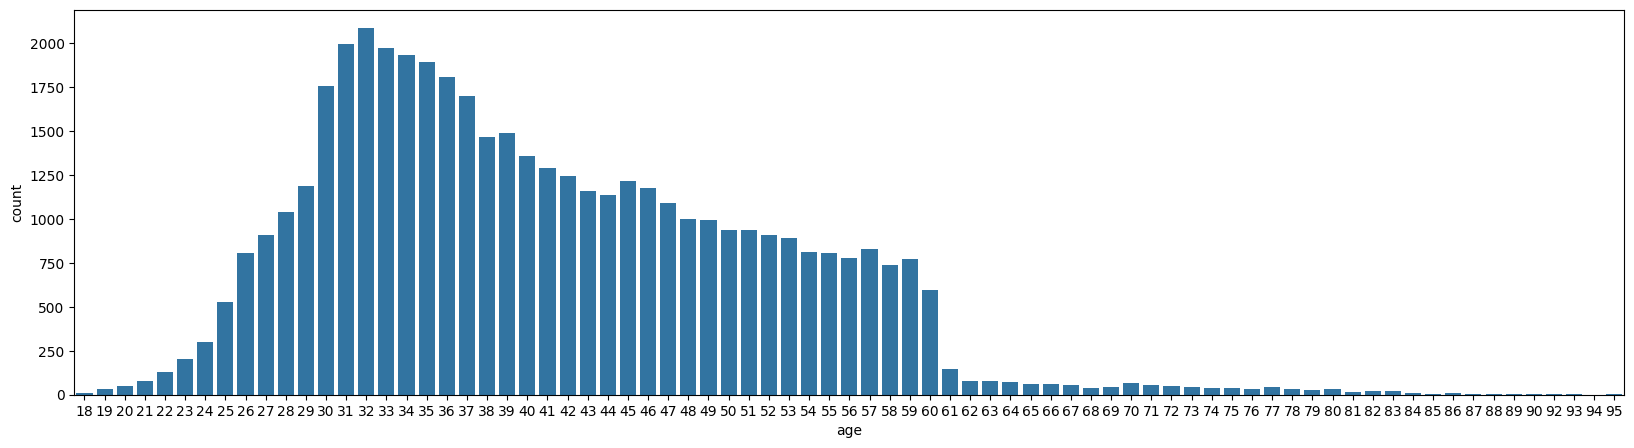

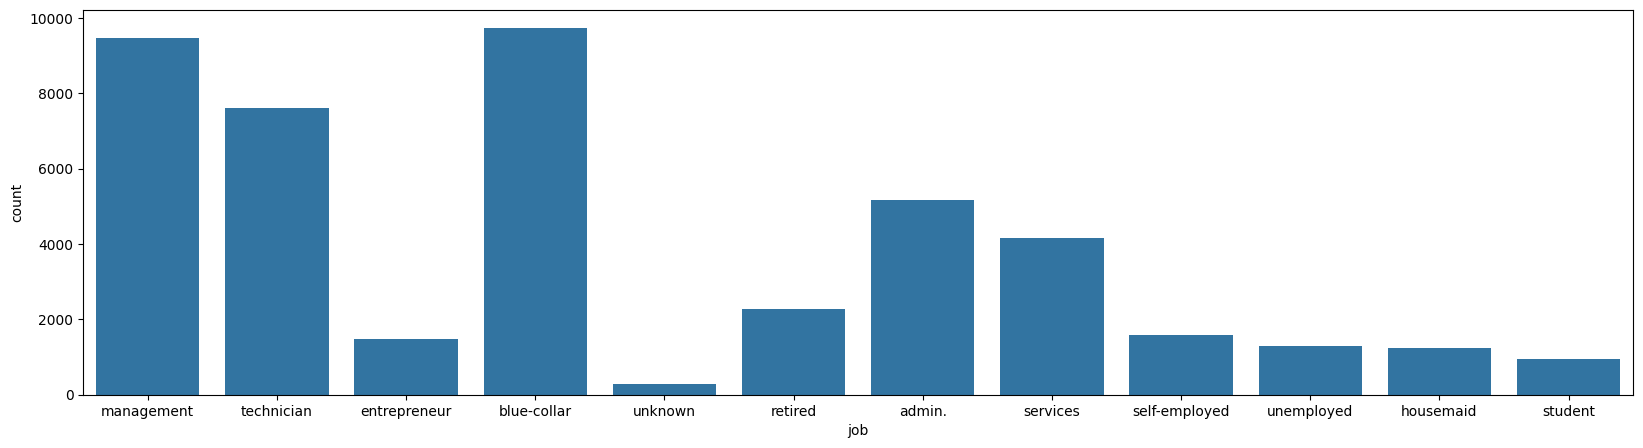

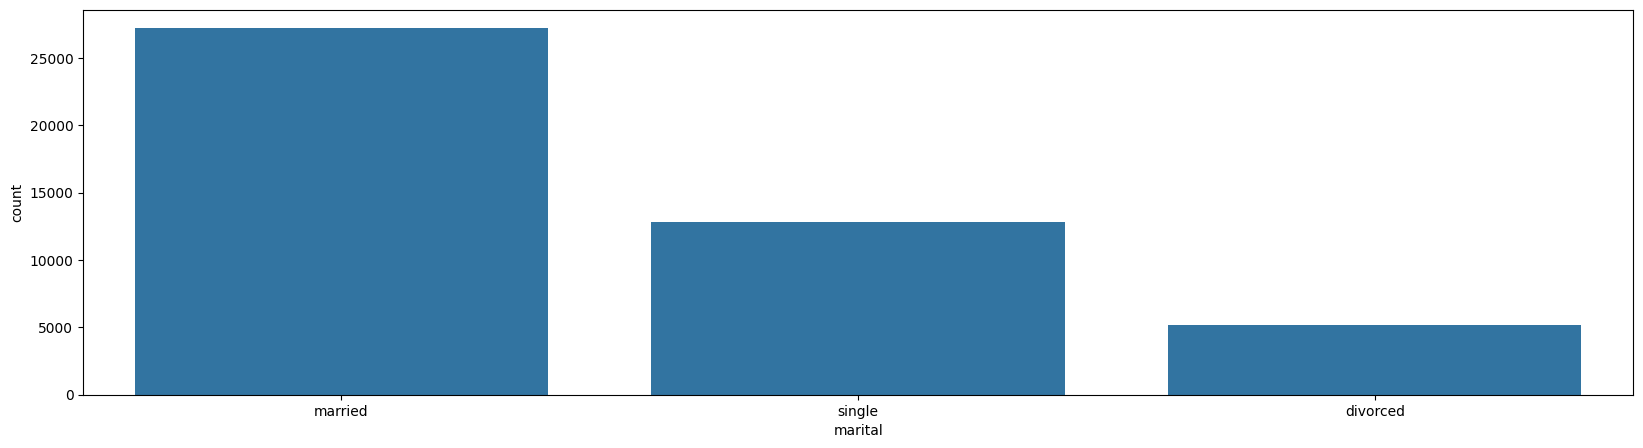

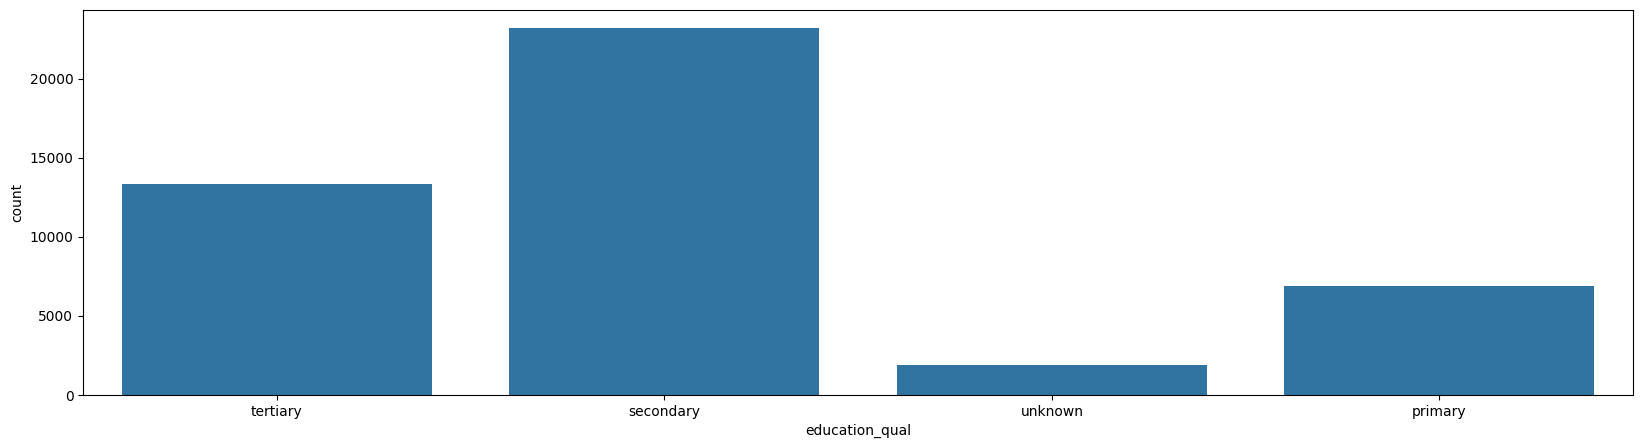

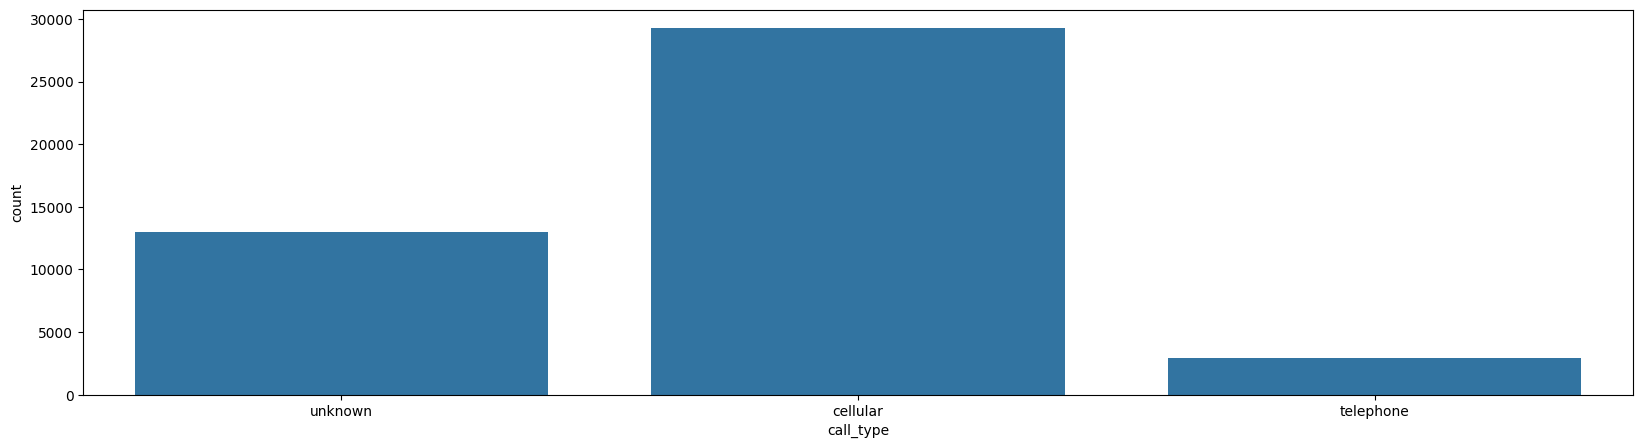

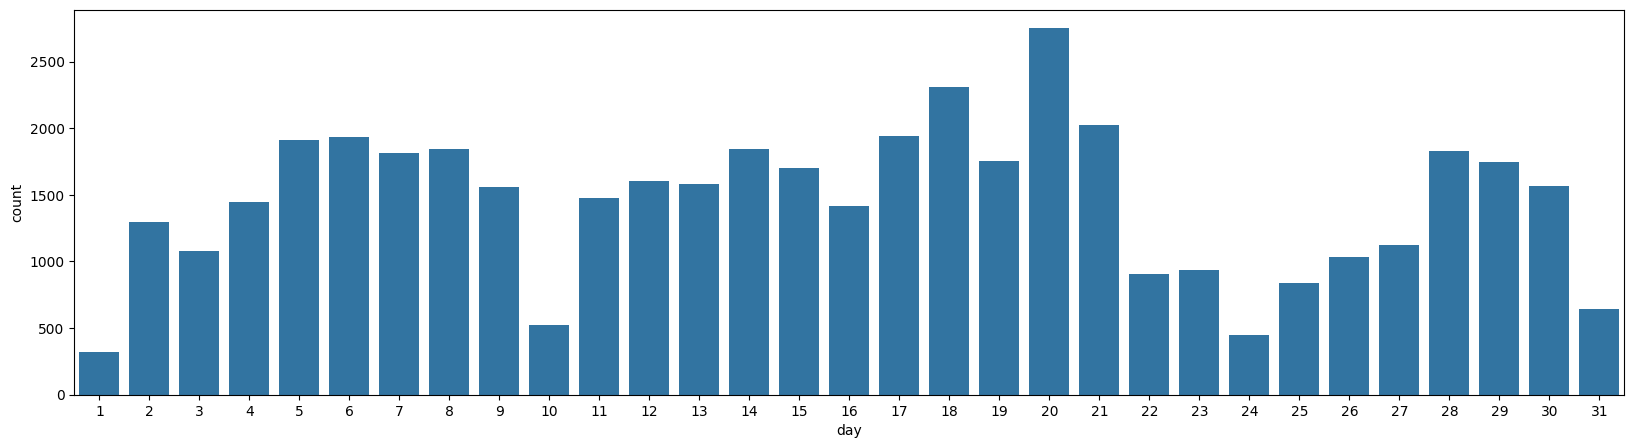

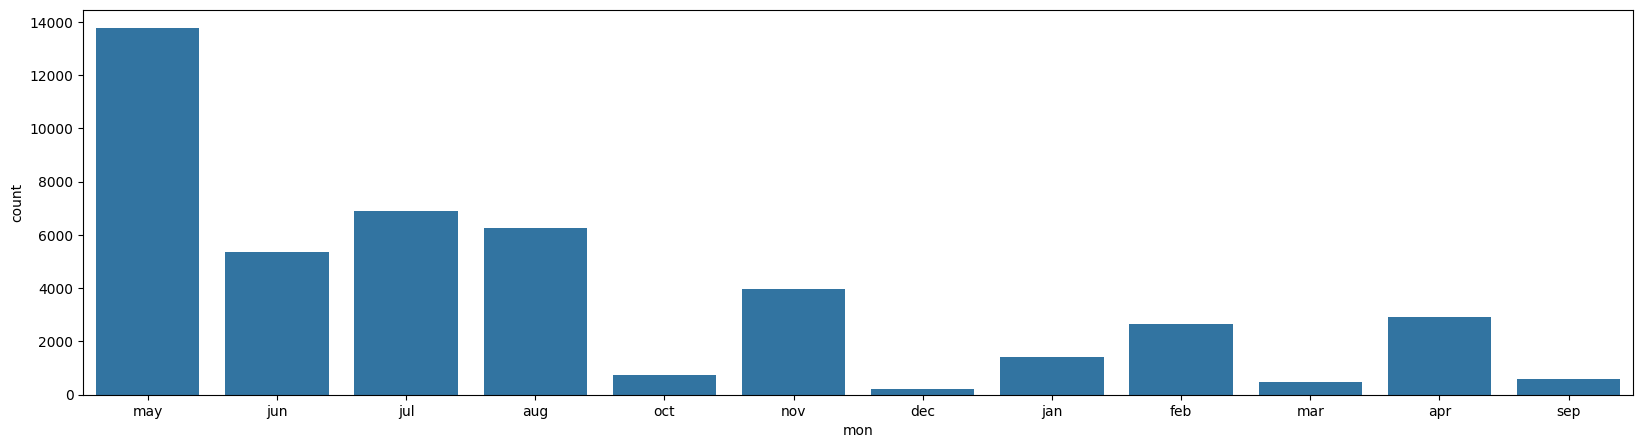

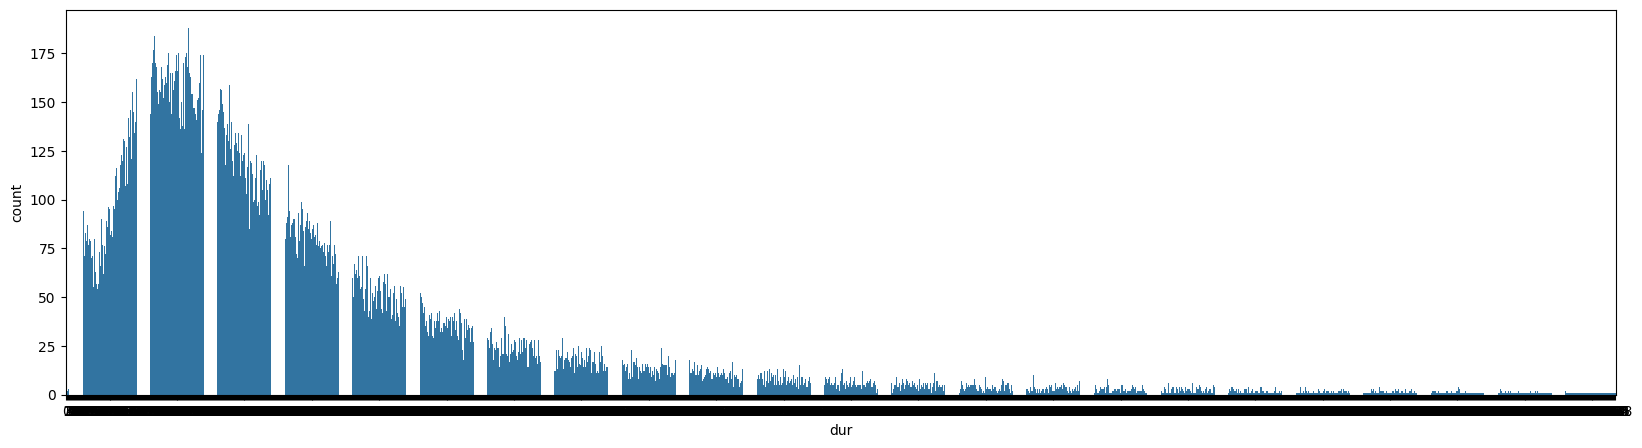

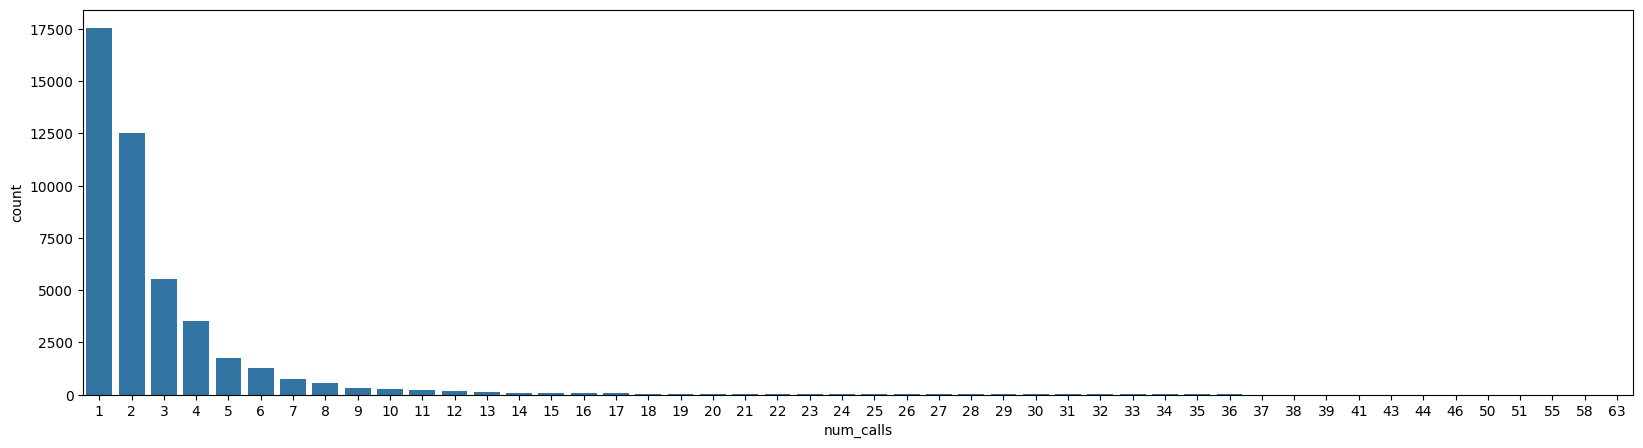

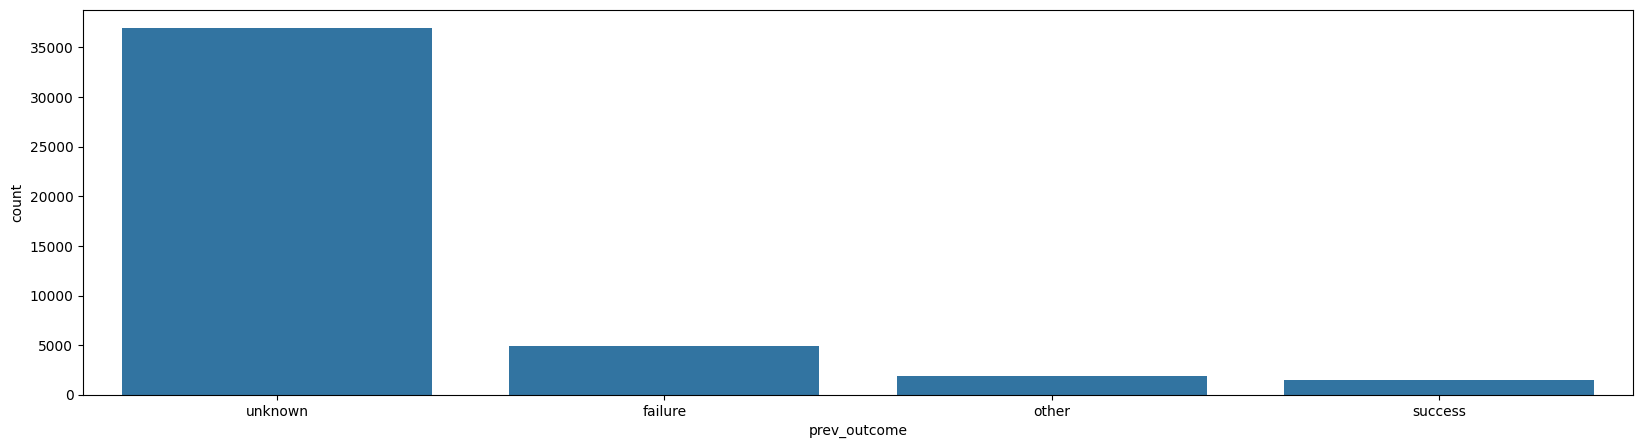

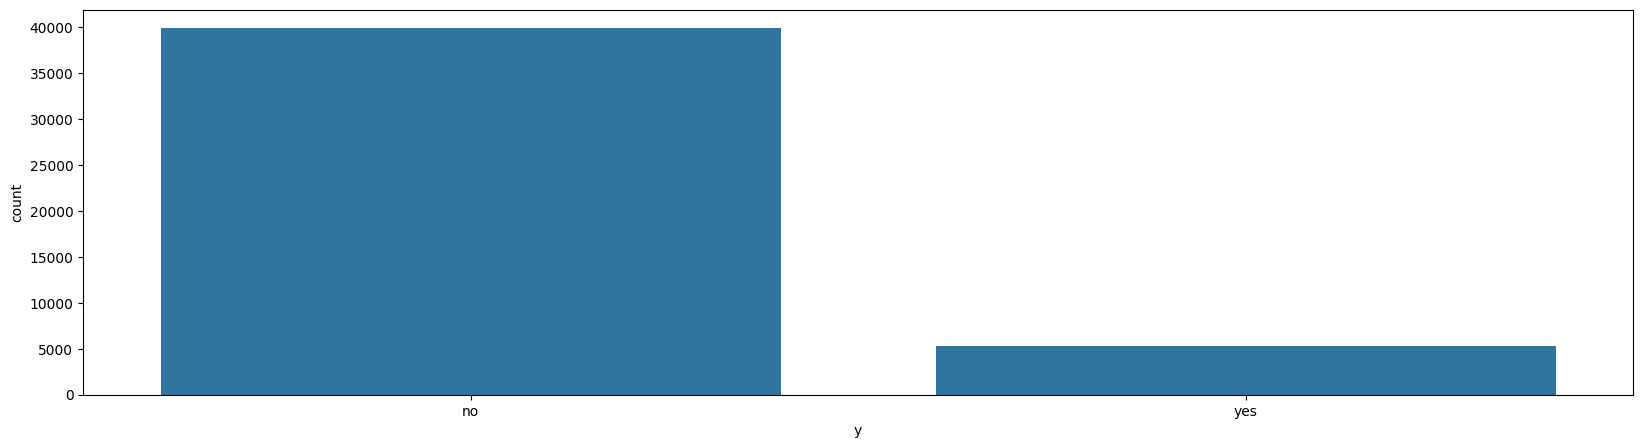

In [ ]:
for i in dataset.columns:
  plt.figure(figsize = (20,5))
  sns.countplot(x=dataset[i])


<Figure size 2000x500 with 0 Axes>

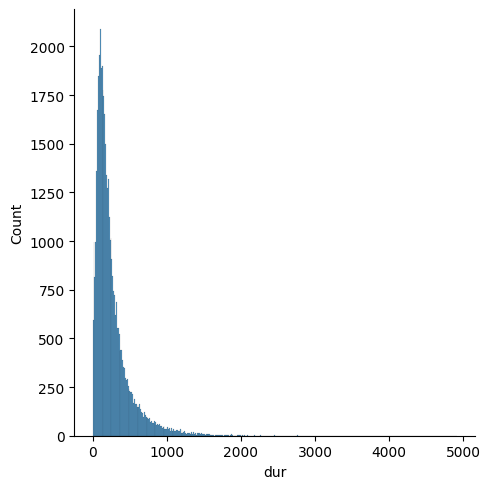

In [ ]:
plt.figure(figsize=(20,5))
sns.displot(x=dataset.dur, kind='hist')

plt.show()


<Axes: xlabel='dur', ylabel='Count'>

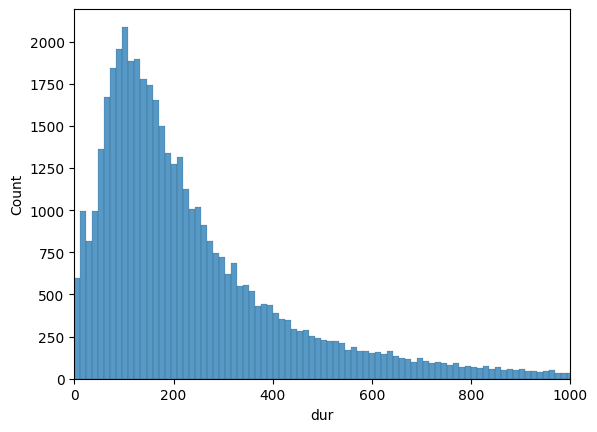

In [ ]:
fig, ax = plt.subplots()

b = sns.histplot(dataset.dur, ax=ax)
ax.set_xlim(0, 1000)
b

# OBSERVATIONS

What the Insurance Company has done so far


1.  Middle aged men (i.e 30-35 age) are targeted more.
2. Blue Collar and Management people are targeted high.
3.  More calls are made to the married.
4.  People who have done their Secondary educations are called more.
5. Cellular type calls are made more.
6. Most number of calls have been made on the 20th day of the month.
7. High number of calls are made in the May month than any other month.
8. Mostly they are calling once only. Average number of calls is 3.
9. Most of the previous outcome of the calls are unknown.
10. Mean duration of the calls is 100 secs.
11. Only few people have subscribed to the insurance. i.e data is highly imbalanced.









# ANALYSIS

In [ ]:
dataset.y

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


In [ ]:
dataset.y.unique()

array(['no', 'yes'], dtype=object)

In [ ]:
dataset.y = dataset.y.map({'no':0,'yes':1})

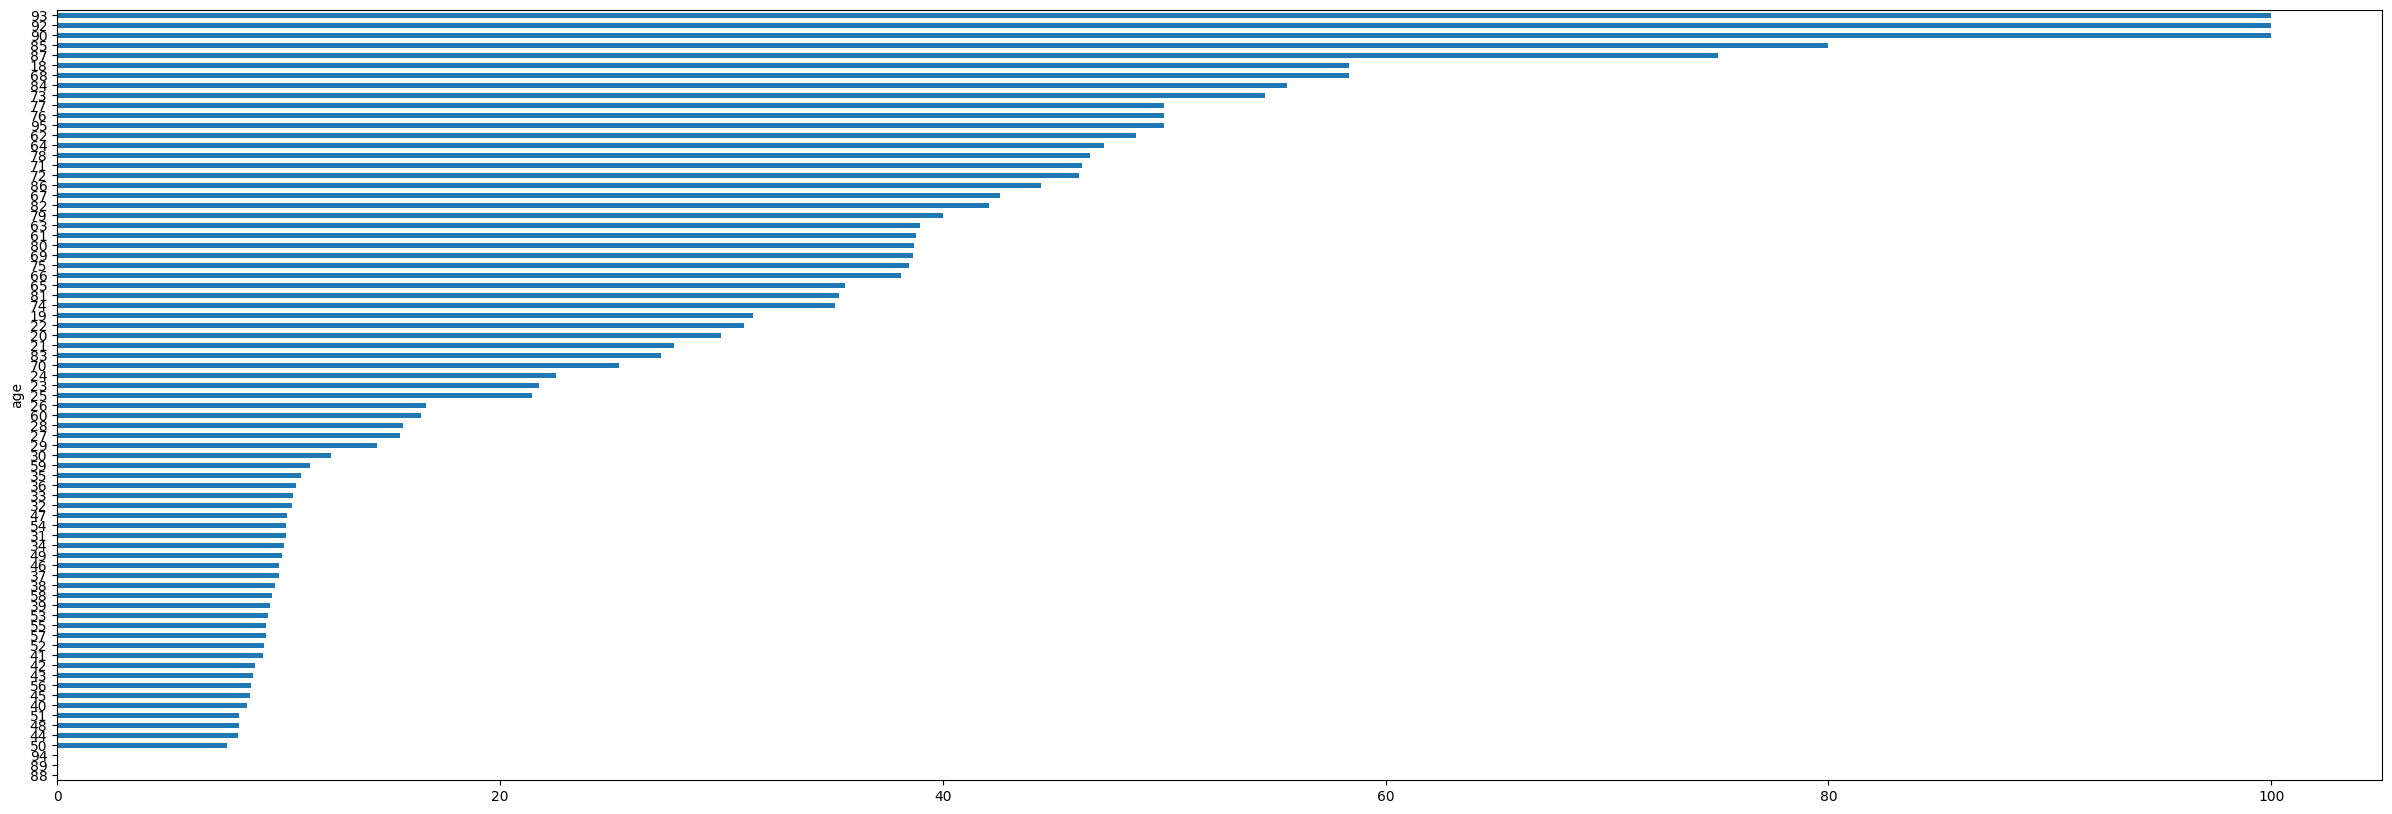

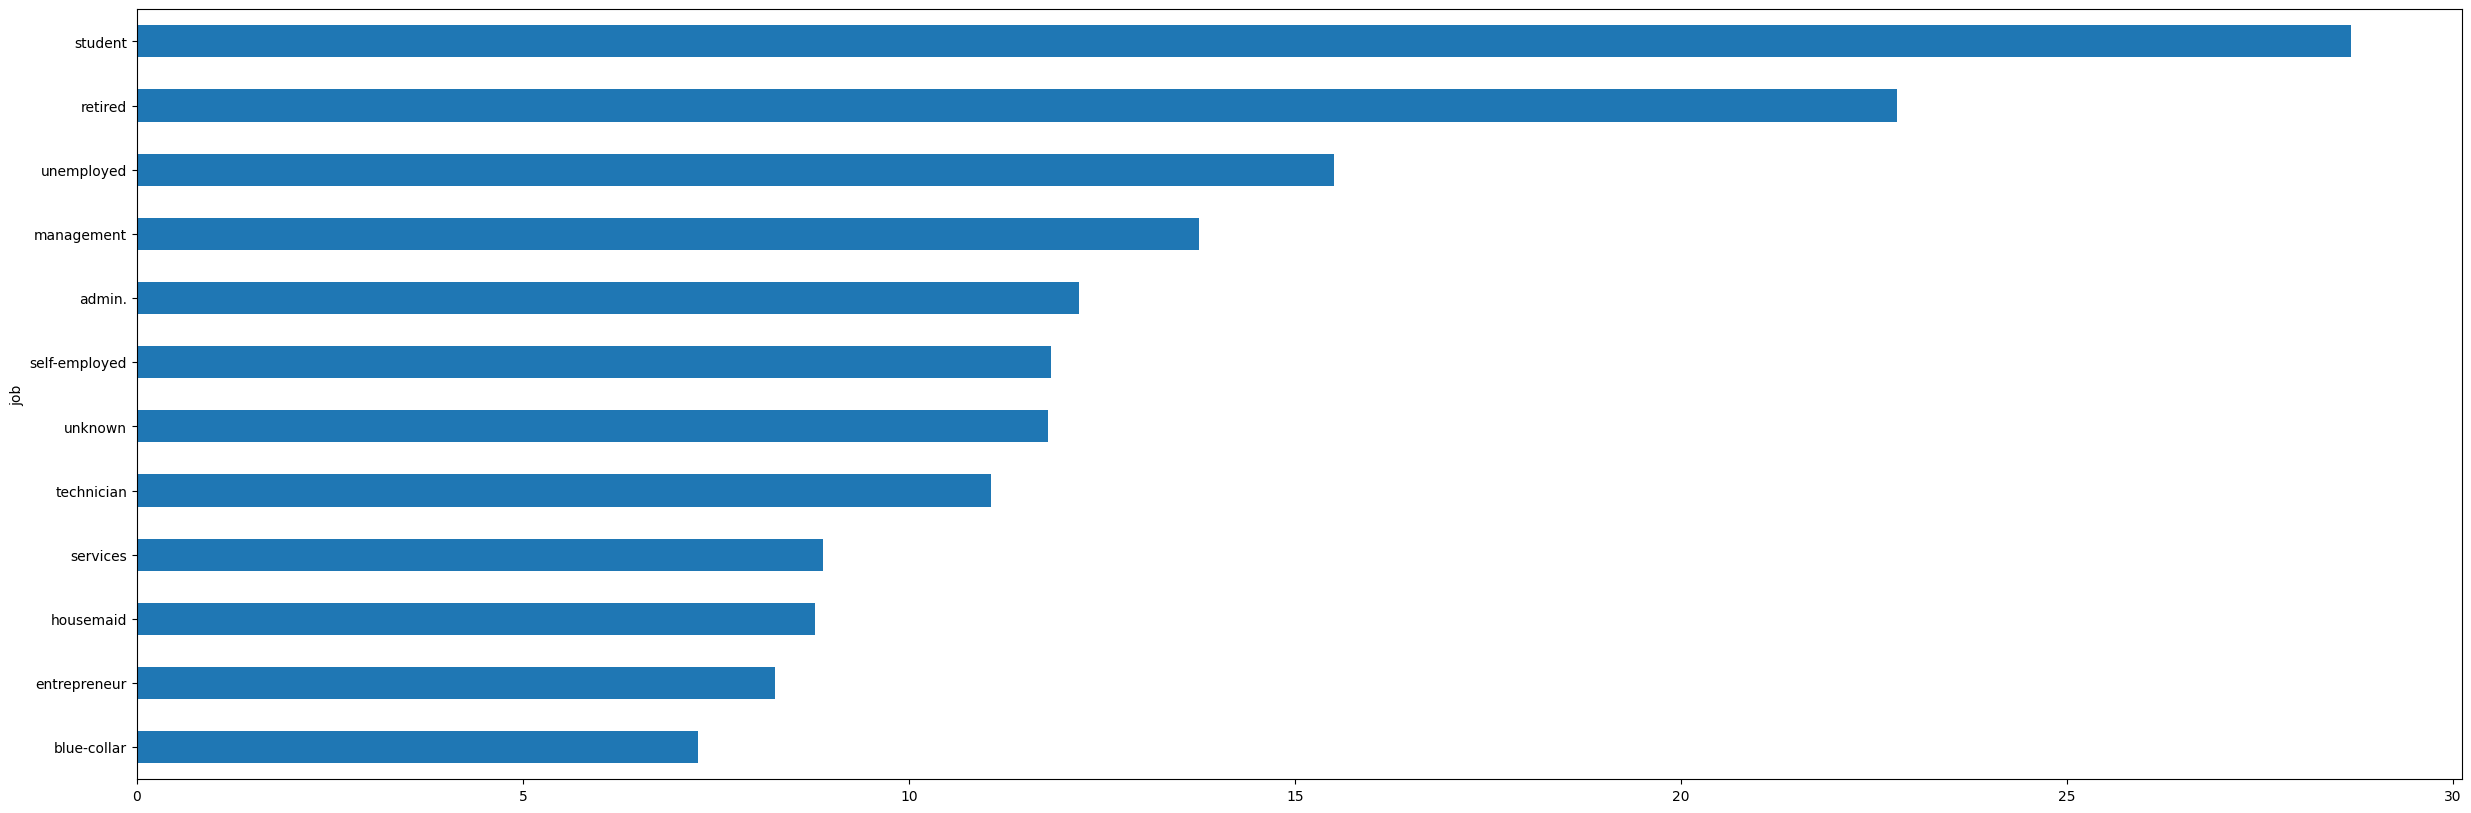

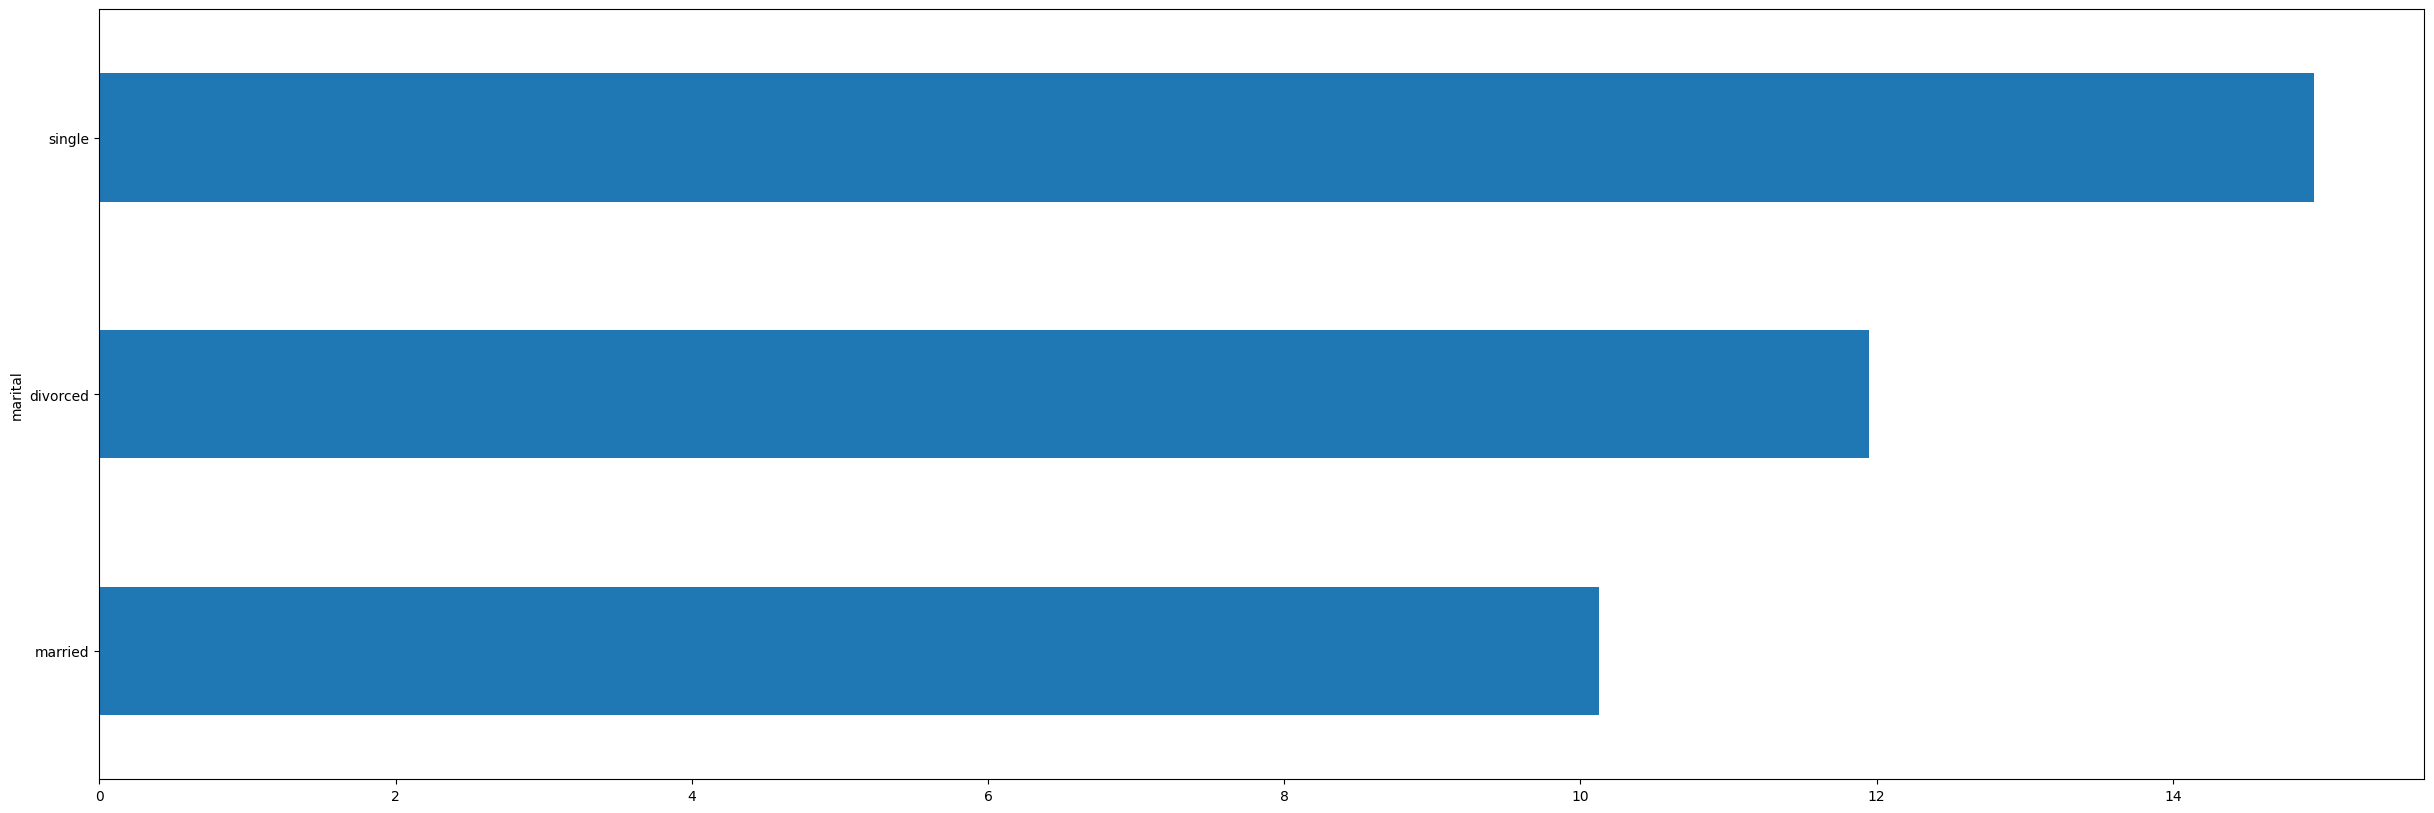

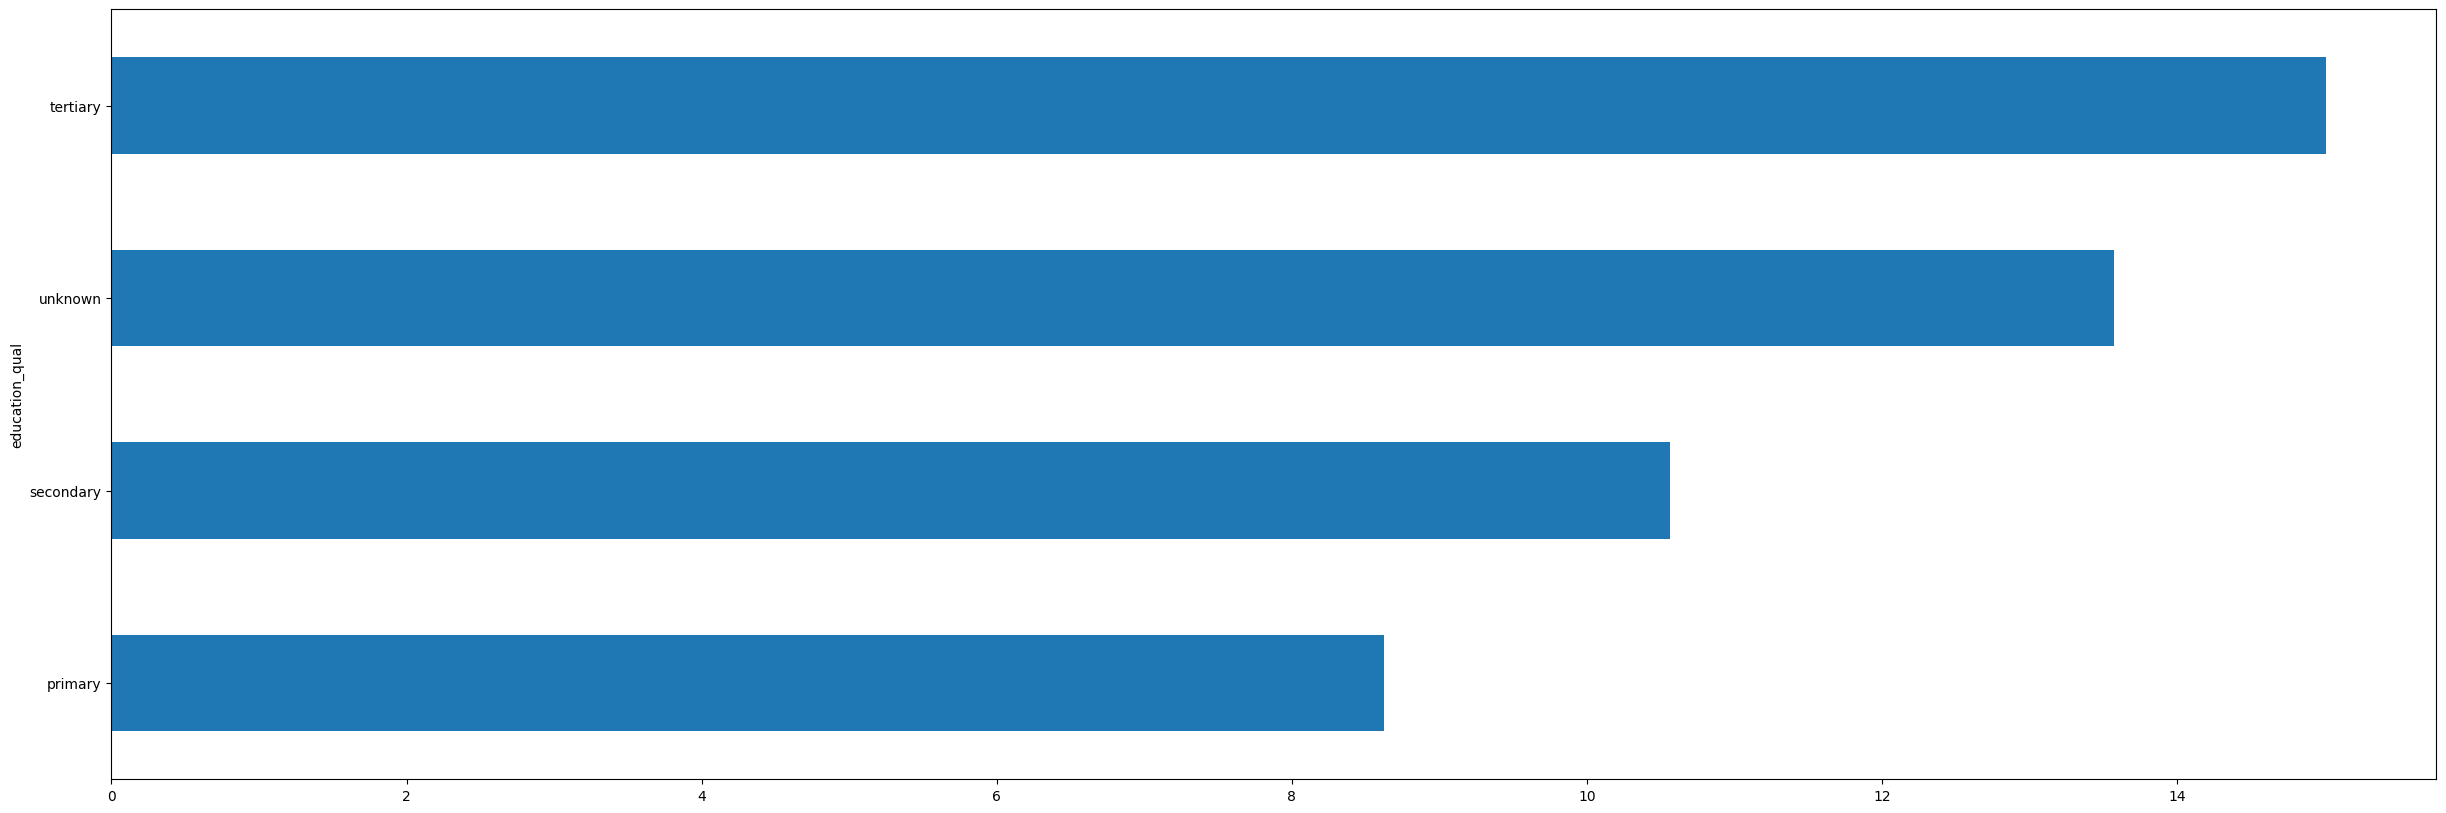

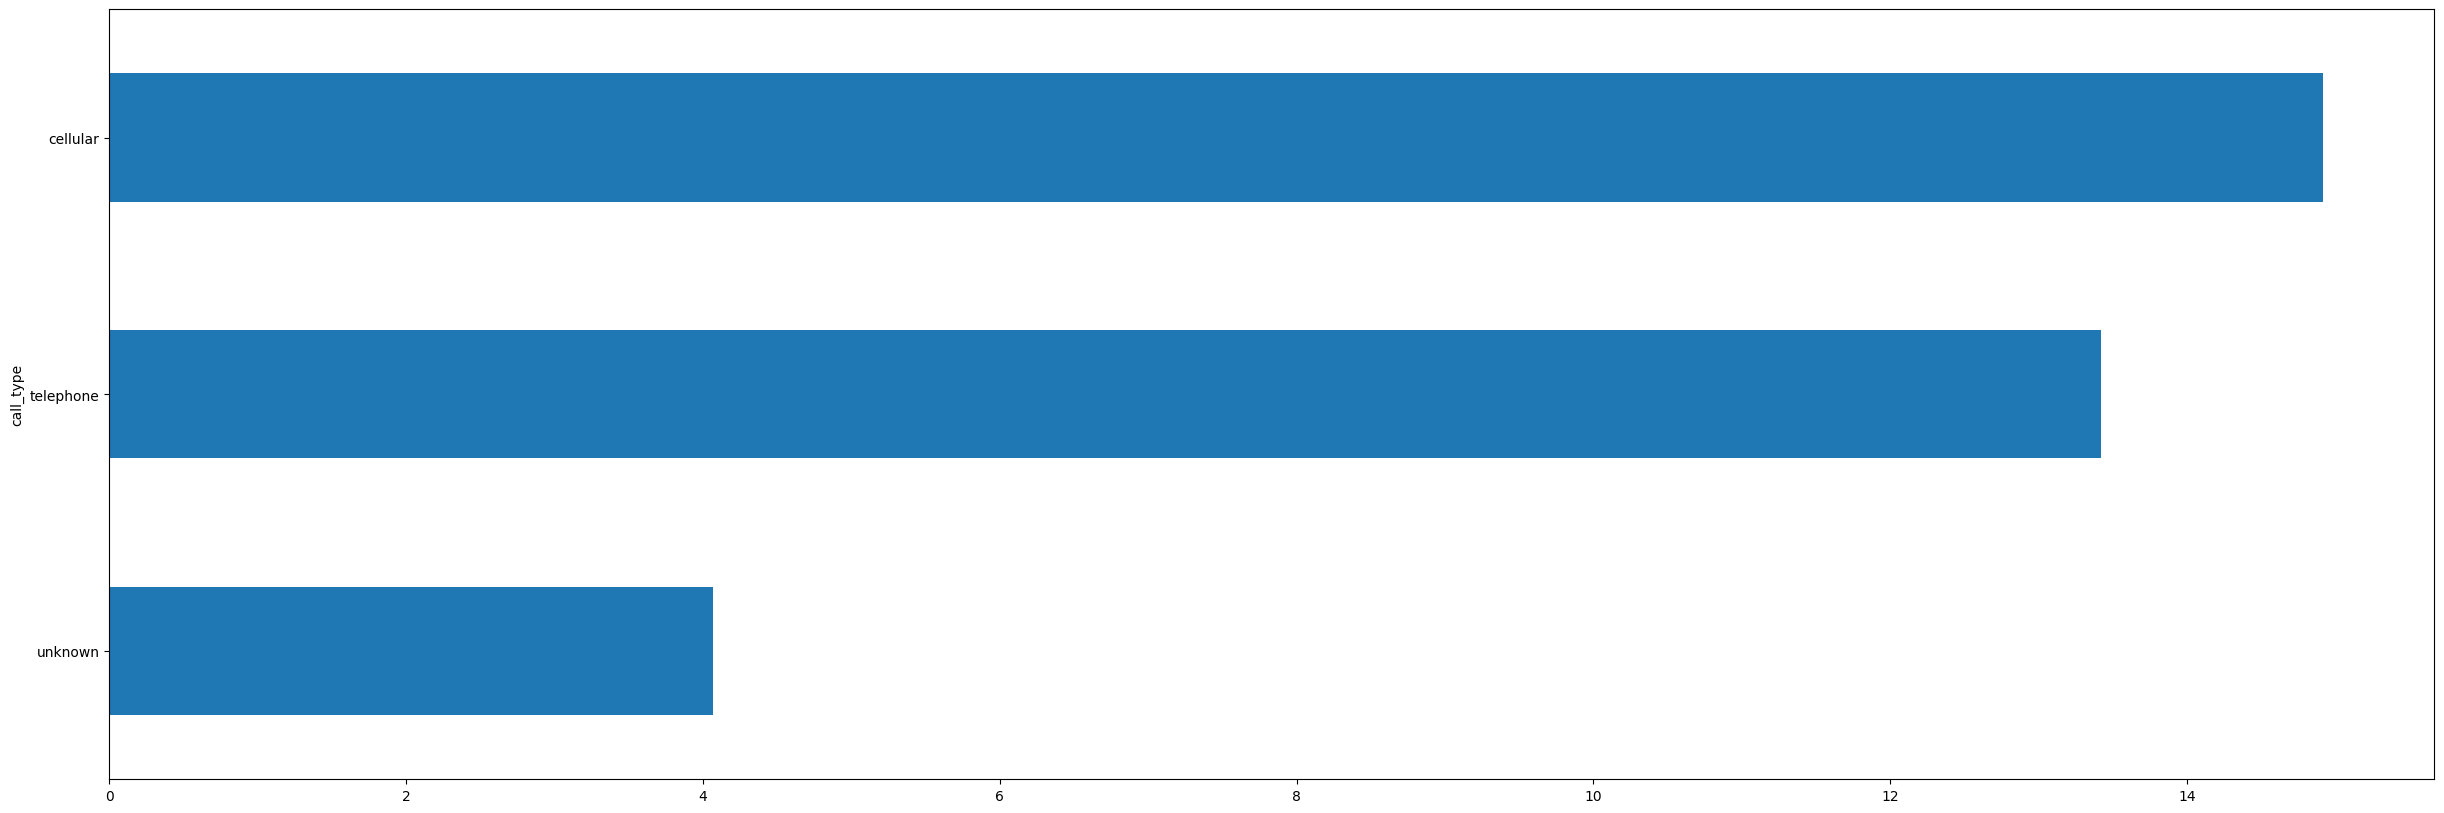

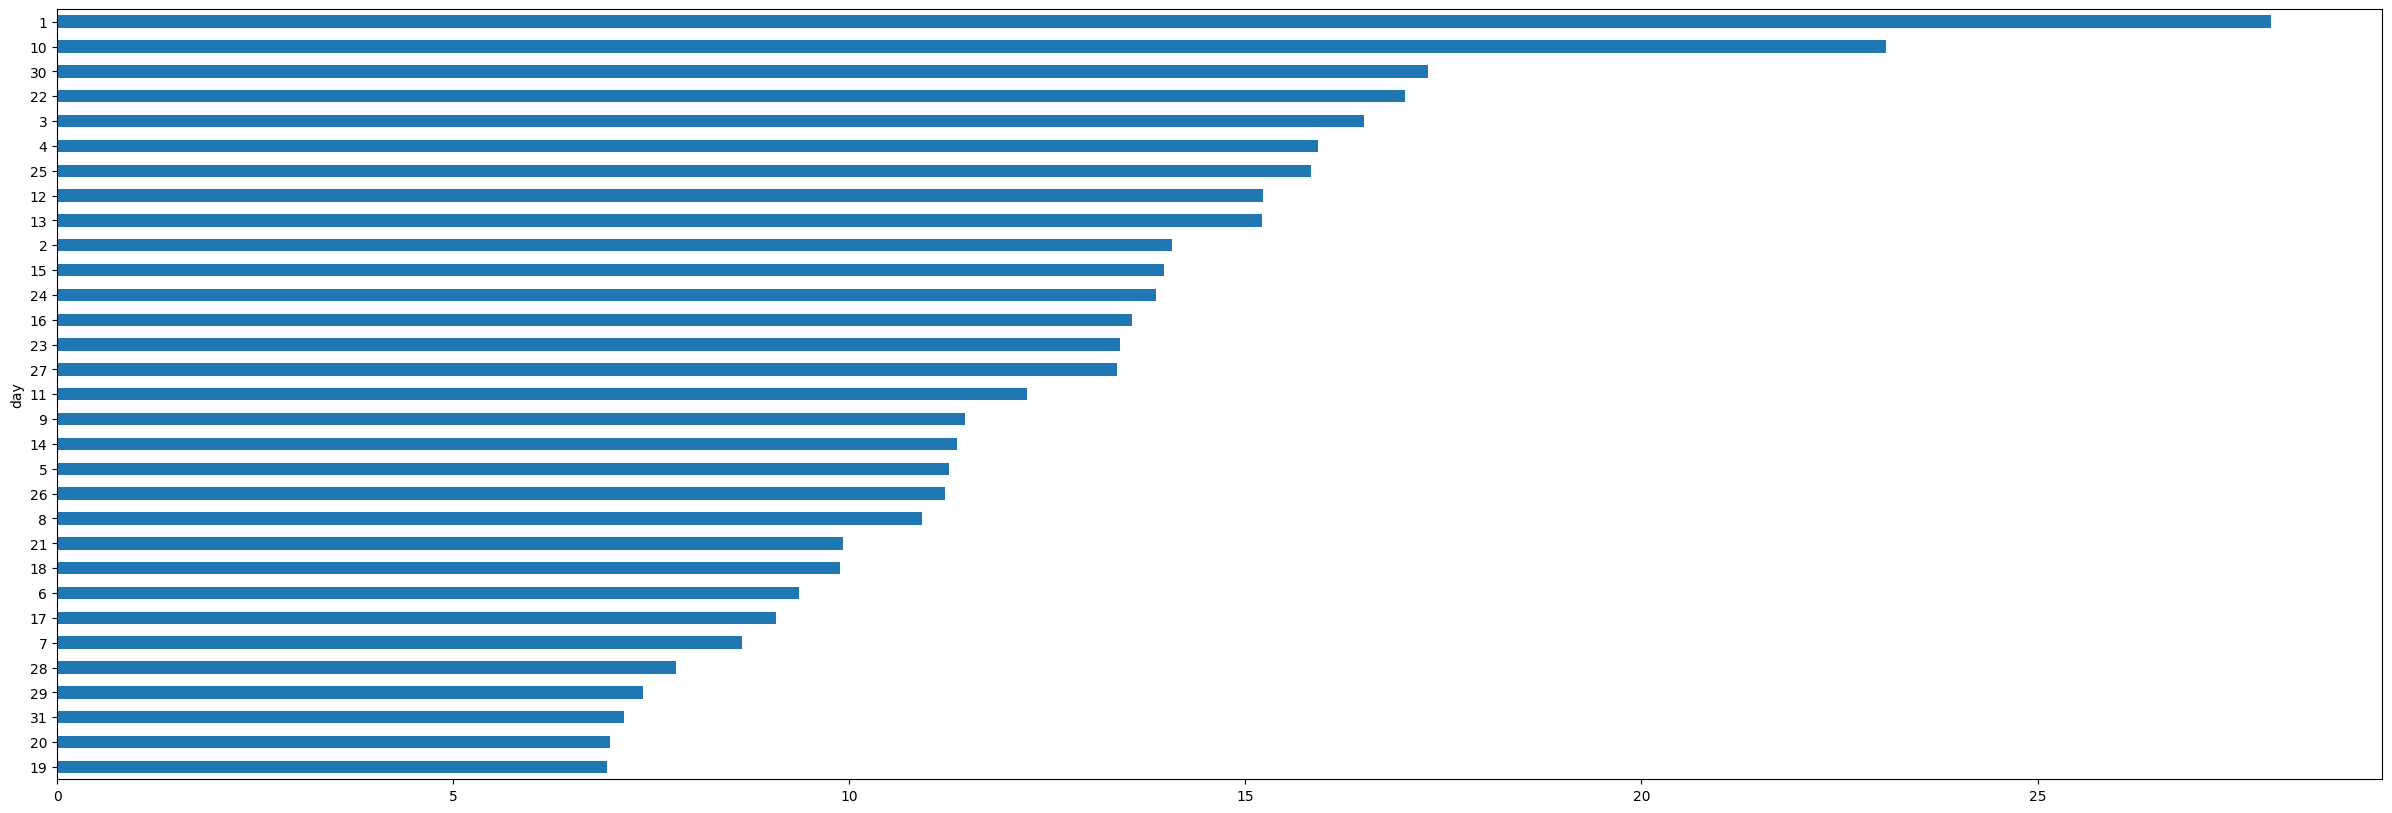

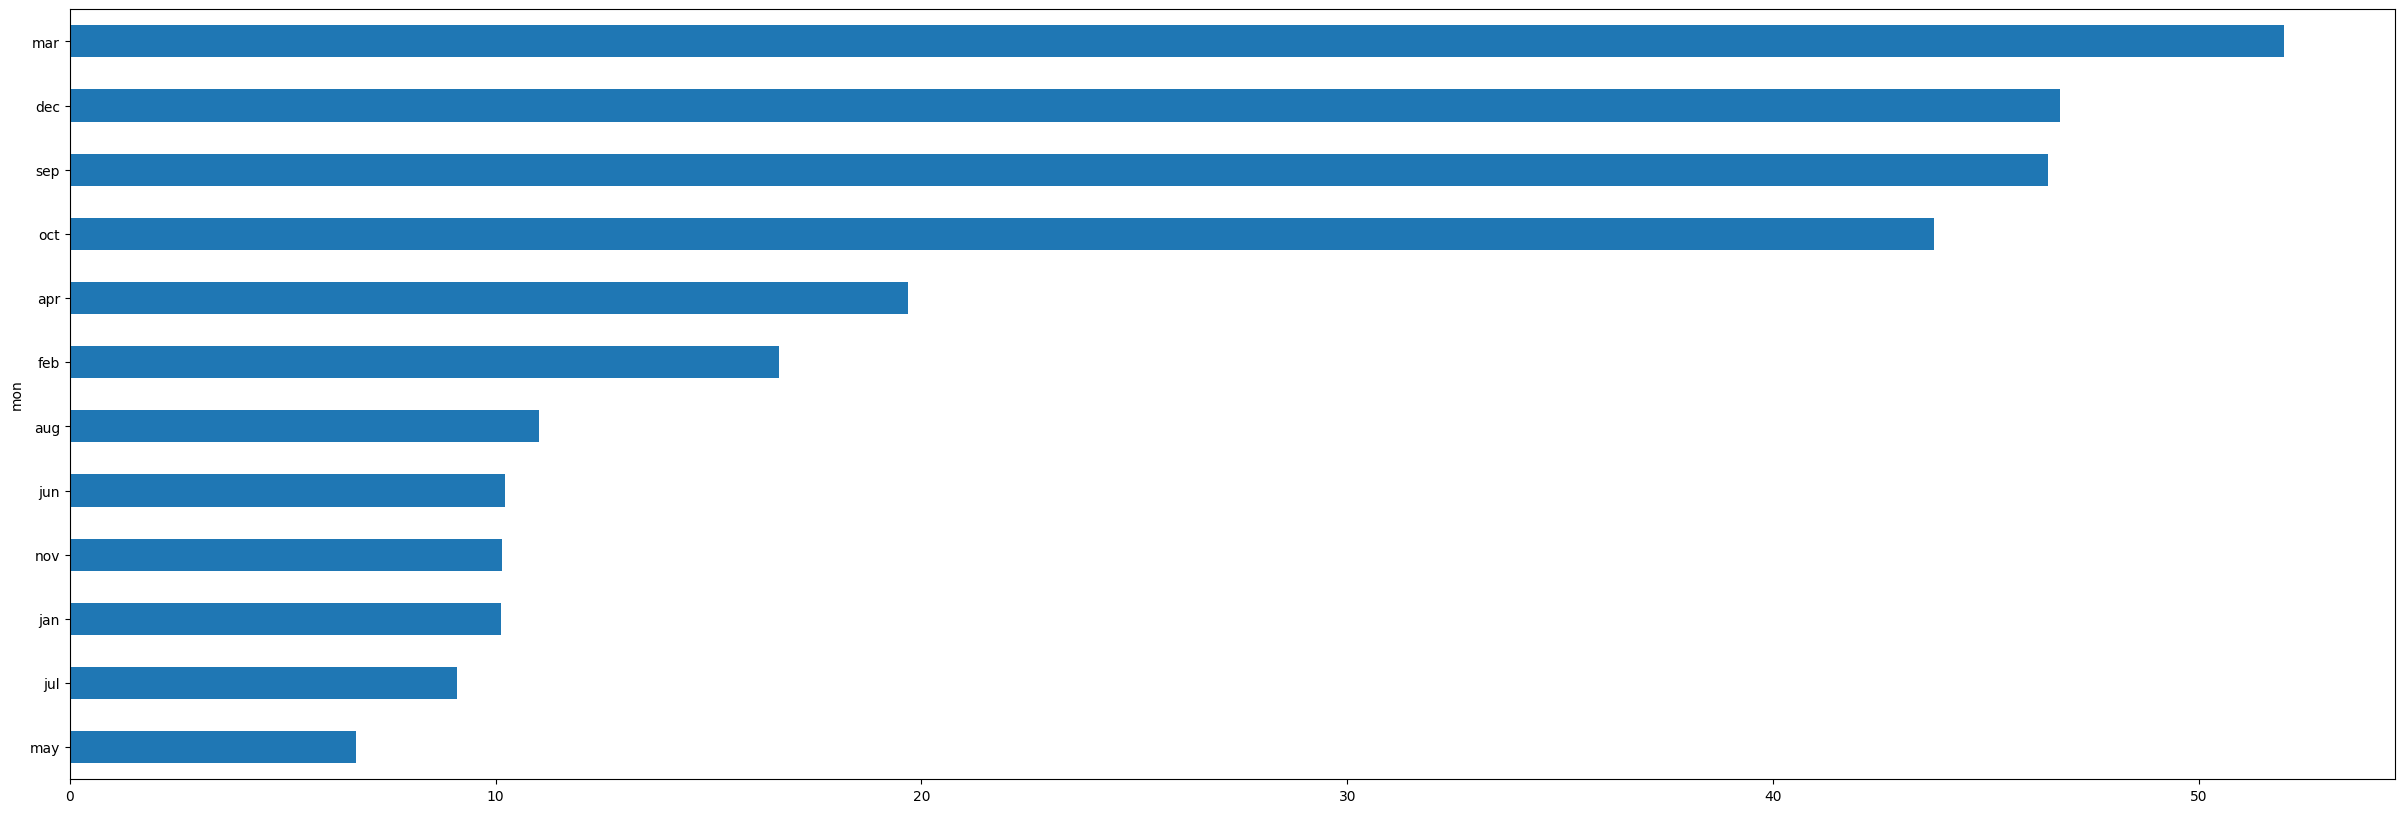

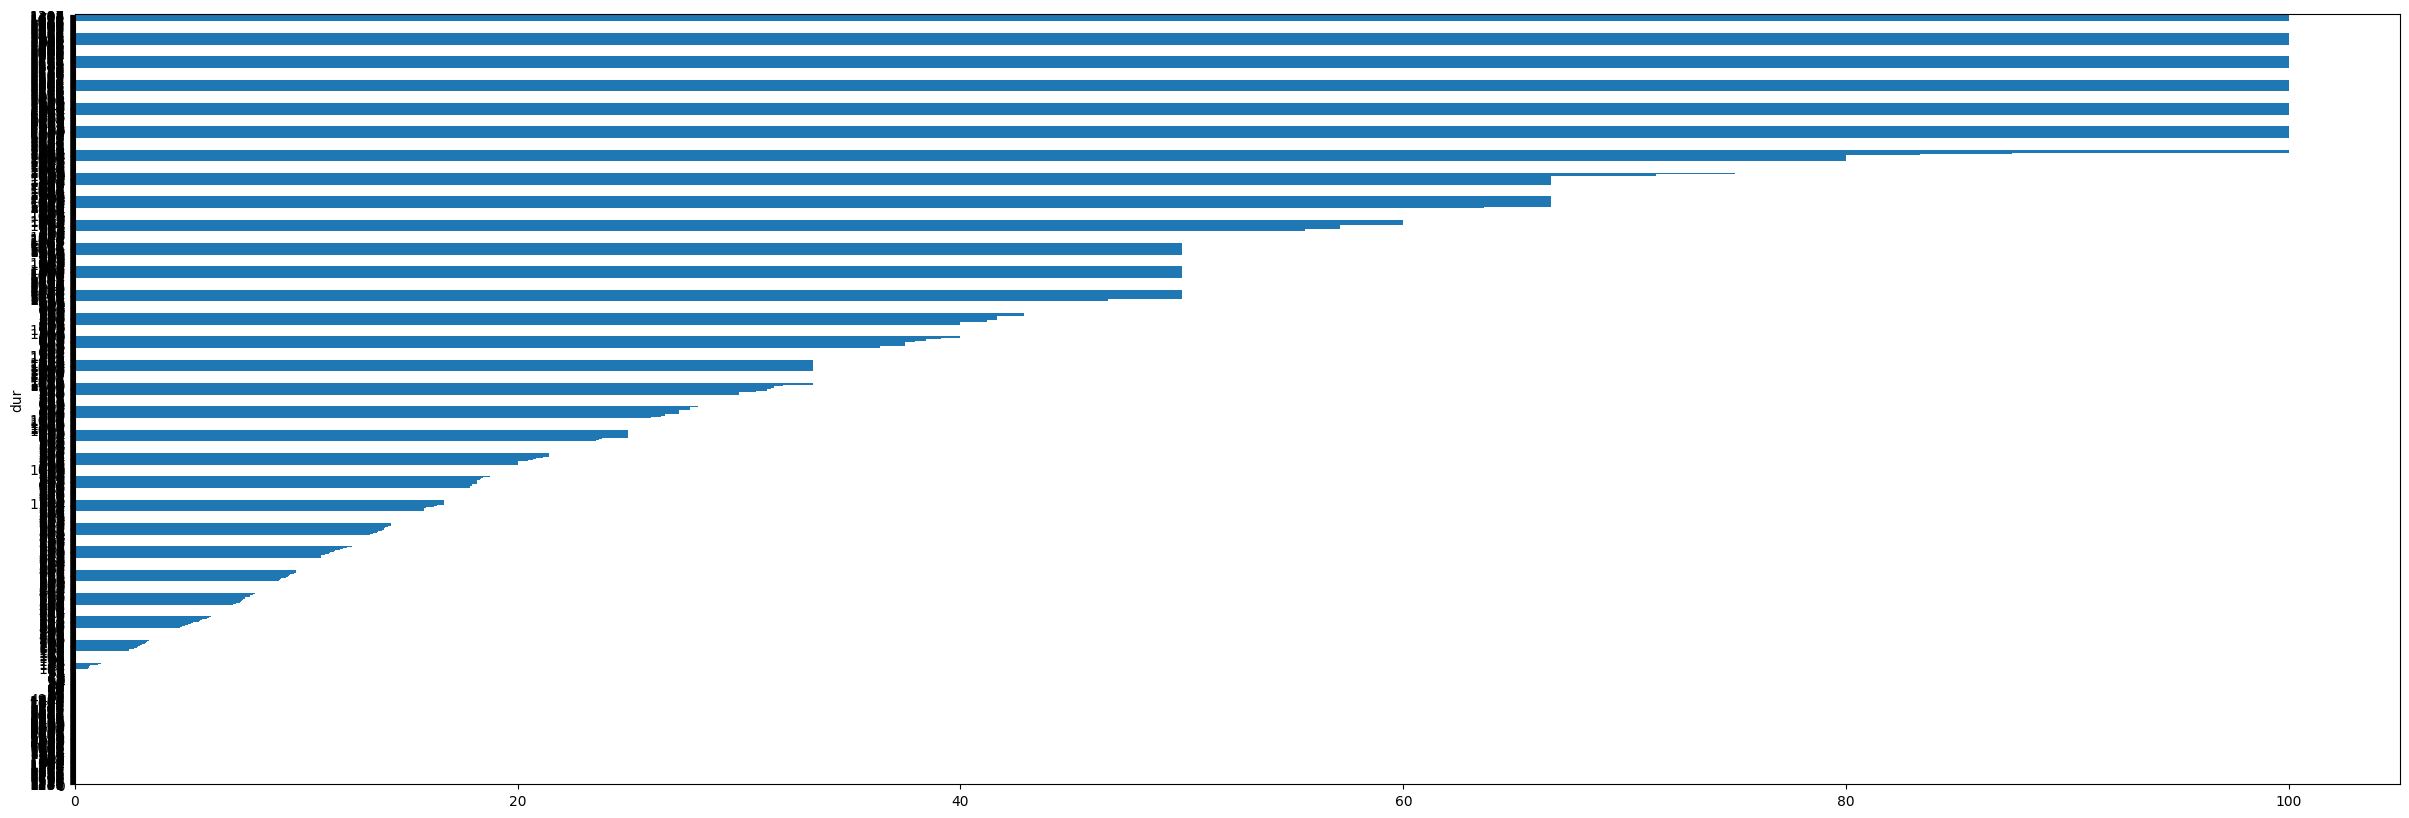

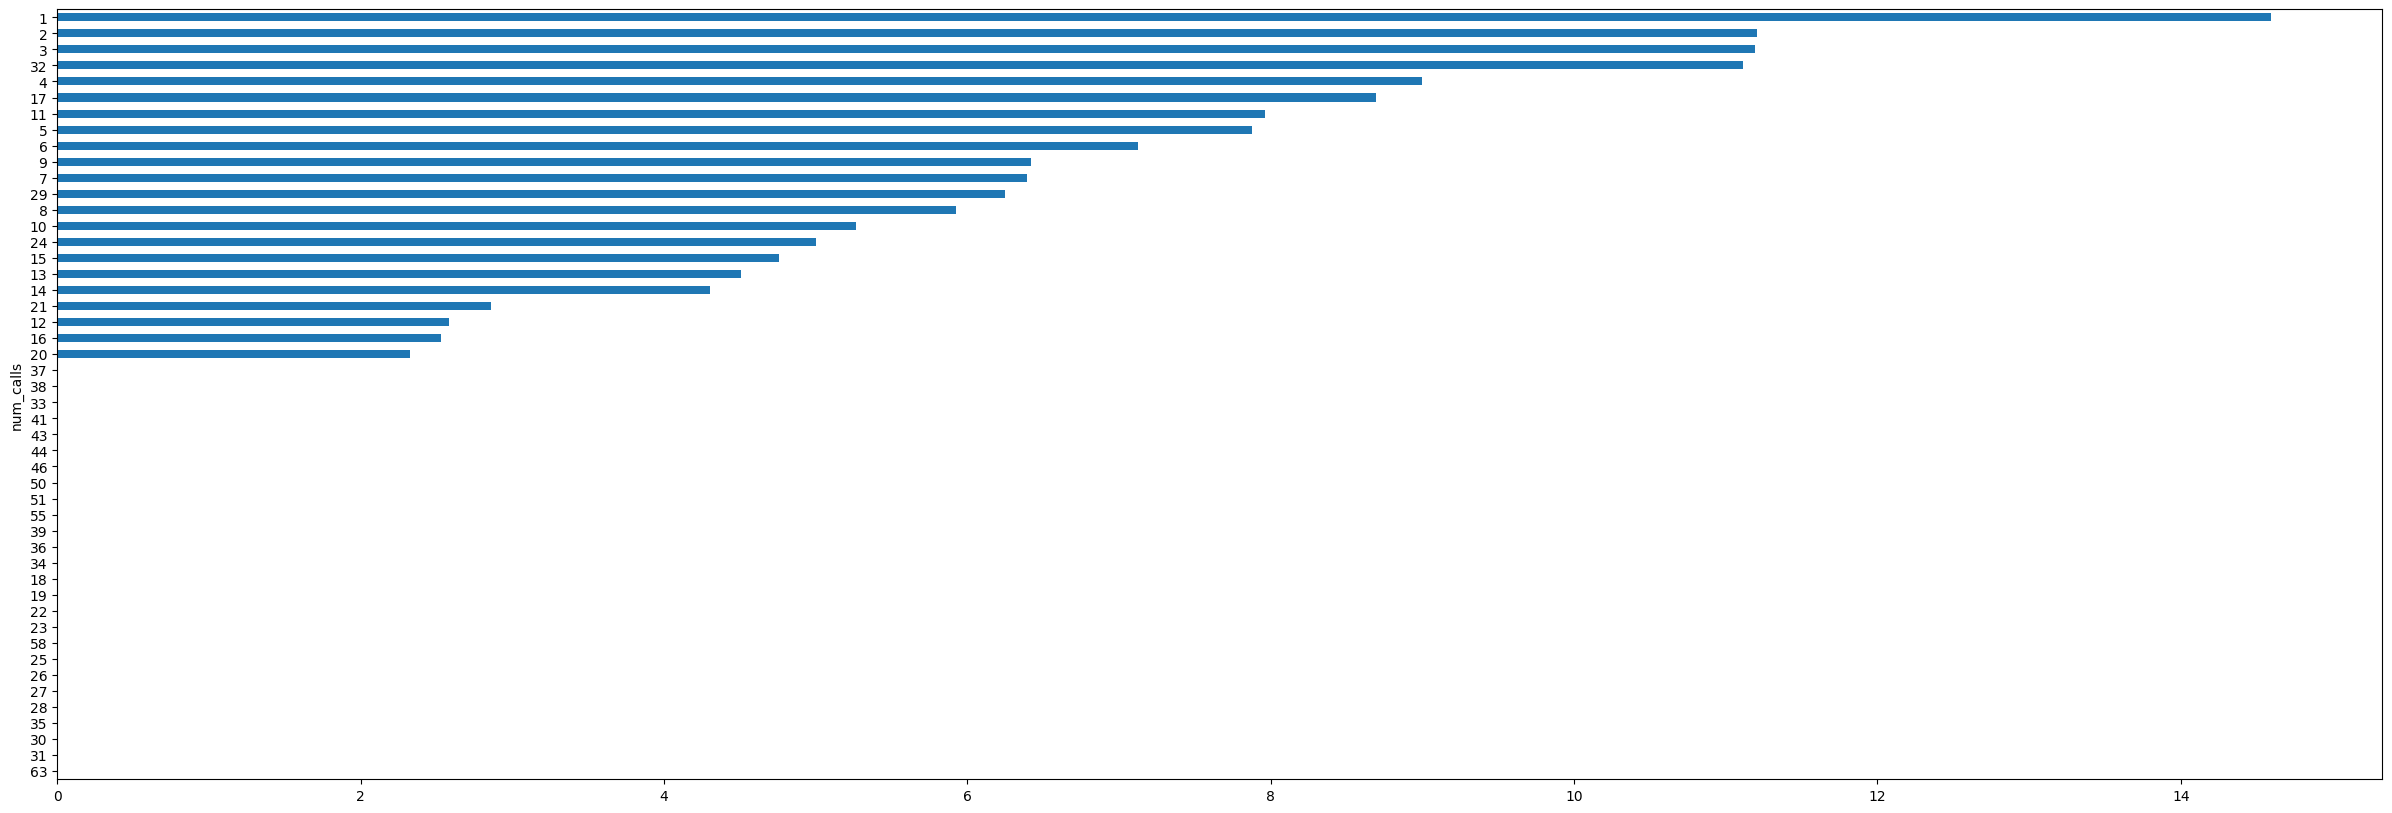

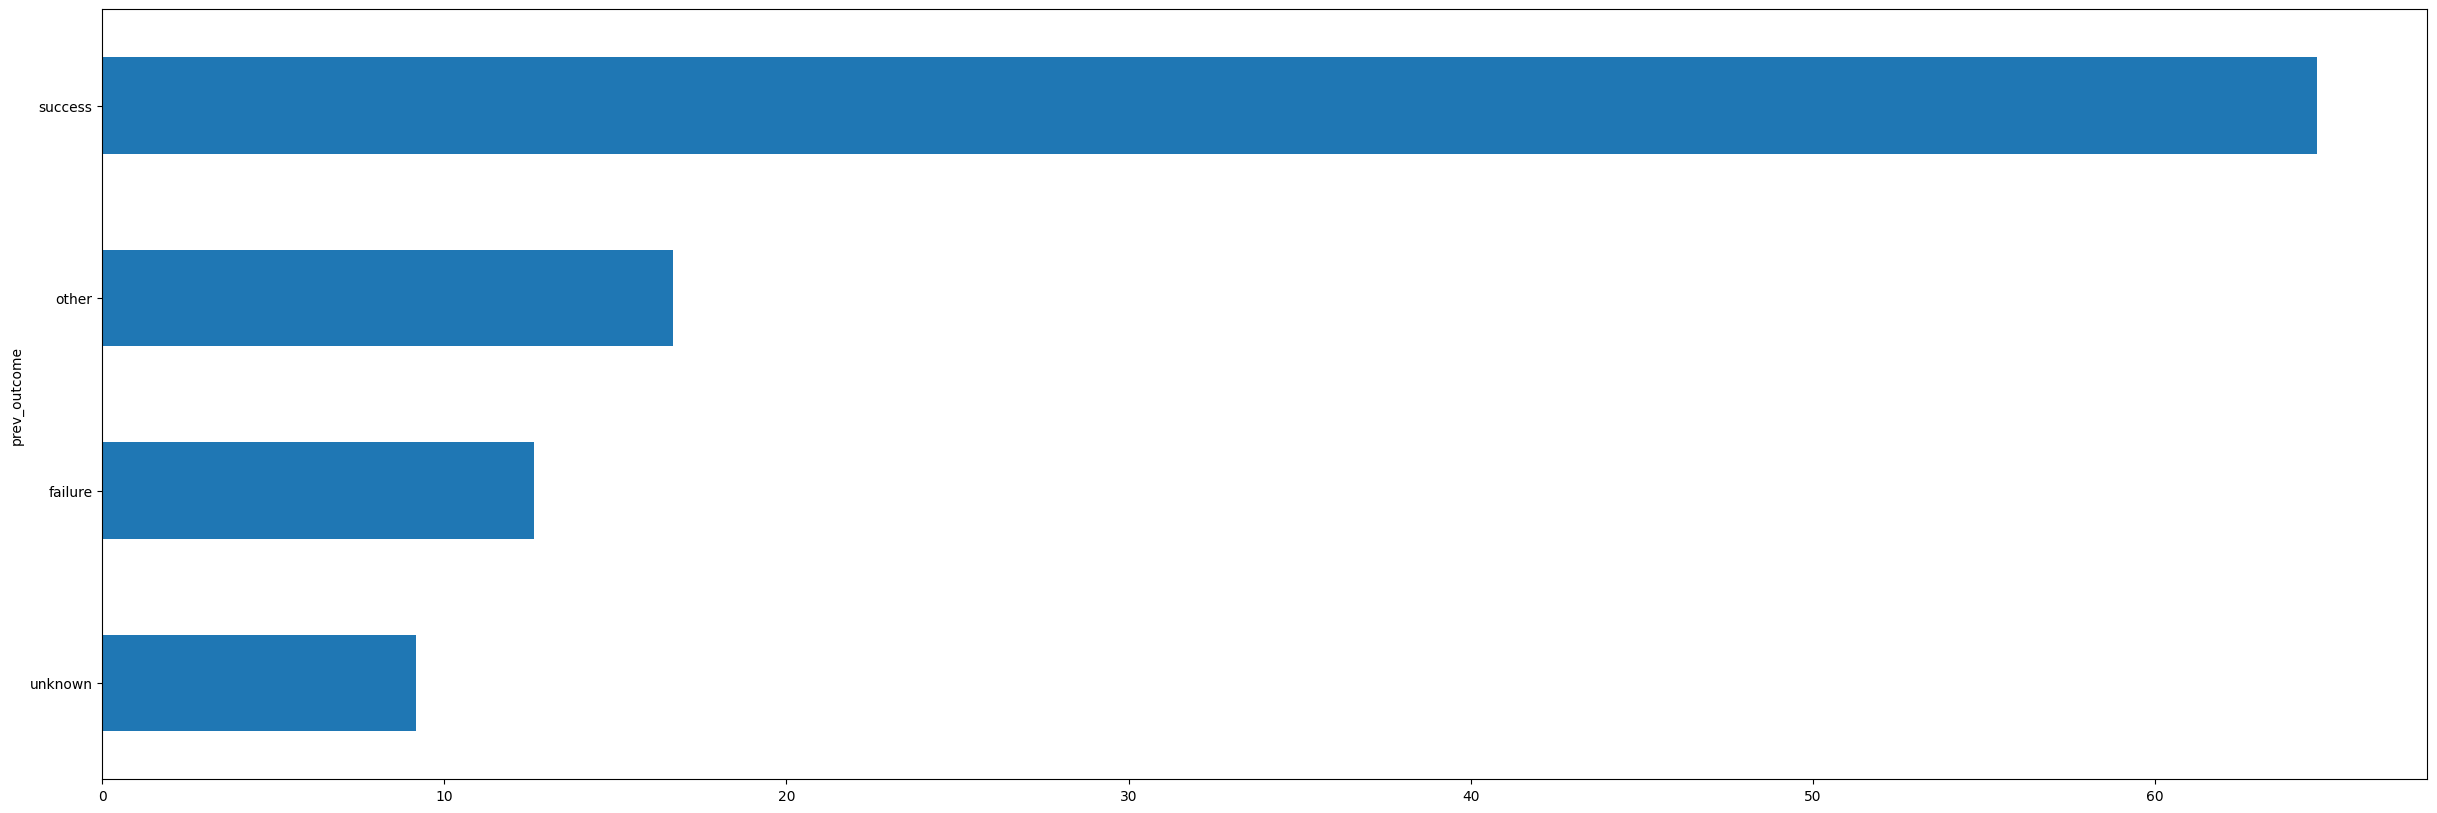

In [ ]:
features = dataset.loc[:,dataset.columns[:10]]
for i in features:
  plt.figure(figsize = (30,10))
  (dataset.groupby(features[i])['y'].mean()*100).sort_values().plot(kind='barh')



**ANALYSIS**

1. Very old age people of age 85-95 have subsribed more.
2. Students have subscribed more to the insurance.
3. Singles have subscribed more to the insurance.
4. People with tertiary education have brought more insurance.
5. Cellular calls have been converted more.
6. More people have brought the insurance on 1st day of the month.
7. In March month, more conversion is there.
8. Most customers have bought it in one call only.
9. Minimum duration of the call should be 200 secs.
10. If the  previous outcome of the call is success, then the customer is more likely to convert.

# INFERENCE (What the Company must do)

The Insurance Company

*   should target more old age people.
*   must speak to Students more than Blue collar or Management people.
*   should target singles more.
*   should try to make more calls on 1st day of the month.
*   should work hard on March month more than May.




# ENCODING

In [ ]:
dataset.mon.unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb',
       'mar', 'apr', 'sep'], dtype=object)

In [ ]:
dataset.mon = dataset.mon.map({'may':5, 'jun':6, 'jul':7, 'aug':8, 'oct':10, 'nov':11, 'dec':12, 'jan':1, 'feb':2,'mar':3, 'apr':4, 'sep':9})

In [ ]:
dataset.education_qual.unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [ ]:
dataset.education_qual = dataset.education_qual.map({'tertiary':3, 'secondary':2, 'unknown':0, 'primary':1})

In [ ]:
dataset.marital.unique()

array(['married', 'single', 'divorced'], dtype=object)

In [ ]:
dataset.marital = dataset.marital.map({'married':24, 'single':16, 'divorced':32})

Marital column I decided to encode on the general age a person will be single, married and divorced instead of the usual 0,1 and 2.

In [ ]:
dataset.call_type = dataset.call_type.map({'unknown':0, 'cellular':1, 'telephone':2})

In [ ]:
dataset.dtypes

,0
age,int64
job,object
marital,int64
education_qual,int64
call_type,int64
day,int64
mon,int64
dur,int64
num_calls,int64
prev_outcome,object


In [ ]:
dataset.prev_outcome.unique()

array(['unknown', 'failure', 'other', 'success'], dtype=object)

In [ ]:
dataset.prev_outcome = dataset.prev_outcome.map({'unknown':2, 'failure':0, 'other':3, 'success':1})

In [ ]:
dataset.job.unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
t = le.fit_transform(dataset.job)
t

array([4, 9, 2, ..., 5, 1, 2])

In [ ]:
dataset.job = t

In [ ]:
dataset.job.unique()

array([ 4,  9,  2,  1, 11,  5,  0,  7,  6, 10,  3,  8])

In [ ]:
dataset.dtypes

,0
age,int64
job,int64
marital,int64
education_qual,int64
call_type,int64
day,int64
mon,int64
dur,int64
num_calls,int64
prev_outcome,int64


In [ ]:
dataset.isnull().sum()

,0
age,0
job,0
marital,0
education_qual,0
call_type,0
day,0
mon,0
dur,0
num_calls,0
prev_outcome,0


In [ ]:
dataset.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
45206,False
45207,False
45208,False
45209,False


#SPLITTING

In [ ]:
X = dataset.loc[:,dataset.columns[:10]]
y = dataset['y']

In [ ]:
X


,age,job,marital,education_qual,call_type,day,mon,dur,num_calls,prev_outcome
0,58,4,24,3,0,5,5,261,1,2
1,44,9,16,2,0,5,5,151,1,2
2,33,2,24,2,0,5,5,76,1,2
3,47,1,24,0,0,5,5,92,1,2
4,33,11,16,0,0,5,5,198,1,2
...,...,...,...,...,...,...,...,...,...,...
45206,51,9,24,3,1,17,11,977,3,2
45207,71,5,32,1,1,17,11,456,2,2
45208,72,5,24,2,1,17,11,1127,5,1
45209,57,1,24,2,2,17,11,508,4,2


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 8)

Class 0: 39922
Class 1: 5289
Proportion of class 0 is  88.3 %


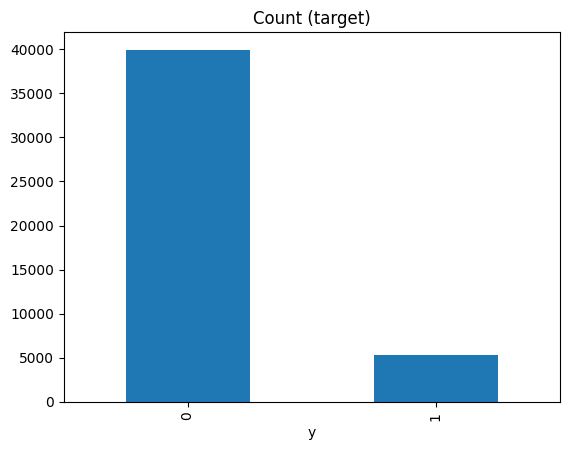

In [ ]:
target_count = dataset.y.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion of class 0 is ', round(target_count[0] * 100 / (target_count[1] + target_count[0]), 2),'%')

target_count.plot(kind='bar', title='Count (target)');

Class 0: 31947
Class 1: 4221
Proportion of class 0 is  88.33 %


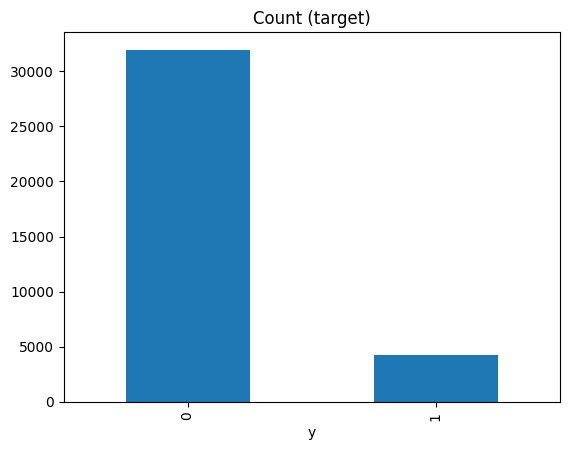

In [ ]:
target_count = y_train.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion of class 0 is ', round(target_count[0] * 100 / (target_count[1] + target_count[0]), 2),'%')

target_count.plot(kind='bar', title='Count (target)');

# BALANCING THE IMBALANCED DATA



In [ ]:
!pip install imblearn

BALANCING using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(sampling_strategy = 'minority')
X_smote , y_smote = smote.fit_resample(X_train,y_train)

Class 0: 31947
Class 1: 31947
Proportion of class 0 is  50.0 %


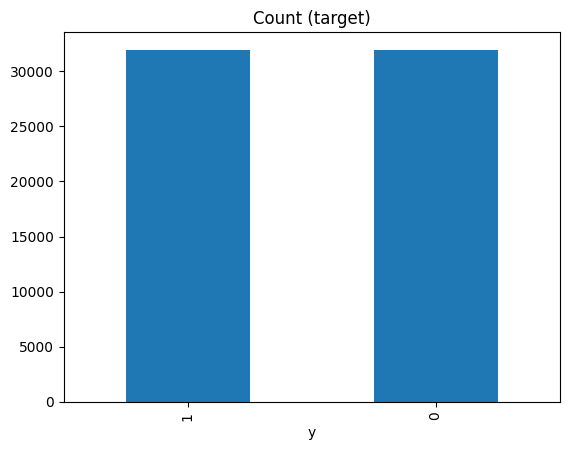

In [ ]:
target_count = y_smote.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion of class 0 is ', round(target_count[0] * 100 / (target_count[1] + target_count[0]), 2),'%')

target_count.plot(kind='bar', title='Count (target)');

BALANCING using Combination of Oversampling and Undersampling

In [ ]:
from imblearn.combine import SMOTETomek

smtmk = SMOTETomek(sampling_strategy = 'minority')
X_smtmk , y_smtmk = smtmk.fit_resample(X_train,y_train)


Class 0: 31737
Class 1: 31737
Proportion of class 0 is  50.0 %


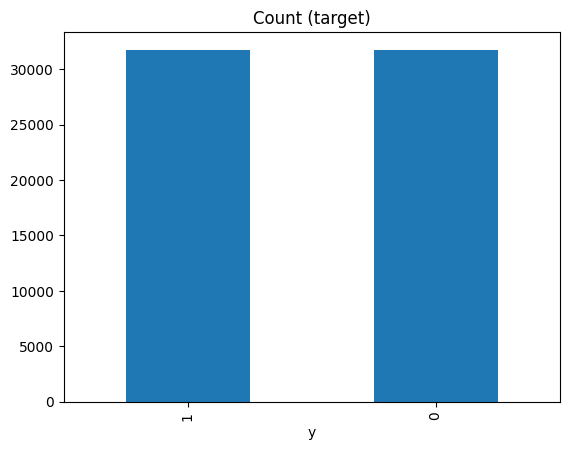

In [ ]:
target_count = y_smtmk.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion of class 0 is ', round(target_count[0] * 100 / (target_count[1] + target_count[0]), 2),'%')

target_count.plot(kind='bar', title='Count (target)');

In [ ]:
from imblearn.combine import SMOTEENN

smtenn = SMOTEENN(sampling_strategy = 'minority')
X_smtenn , y_smtenn = smtenn.fit_resample(X_train,y_train)


Class 0: 23107
Class 1: 30265
Proportion of class 0 is  43.29 %


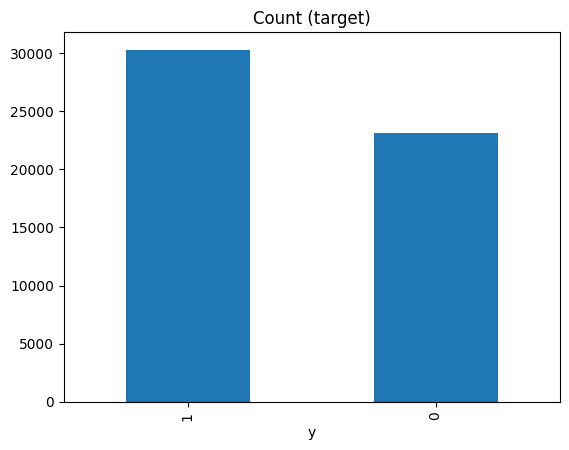

In [ ]:
target_count = y_smtenn.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion of class 0 is ', round(target_count[0] * 100 / (target_count[1] + target_count[0]), 2),'%')

target_count.plot(kind='bar', title='Count (target)');

#MODELLING

# 1. LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_smote,y_smote)
y_pred_lr_1 = lr.predict(X_test)

y_pred_lr_1

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score


In [ ]:
f1_lr1 = f1_score(y_test,y_pred_lr_1)
f1_lr1

0.42004078065831635

In [ ]:
pred_probs_lr1= lr.predict_proba(X_test)
auc_score_lr1 = roc_auc_score(y_test, pred_probs_lr1[:,1])
auc_score_lr1

0.8223721132283706

The AUROC score was good , But the F1 score was poor. Even though the evauation metric for the problem was AUROC, based on the domain F1 score will be the important metric so as to reduce the false negatives. Hence, I wanted to give an overall good and reliable model.

I decided to go with the top most models present - Random Forest and XGBoost.

# 2. RANDOM FOREST

Random forest with SMOTE dataset

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_smote,y_smote)

y_pred_rf1 = rf.predict(X_test)
y_pred_rf1

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
f1_rf1 = f1_score(y_test,y_pred_rf1)
f1_rf1

0.5749285422621478

In [ ]:
pred_probs_rf1= rf.predict_proba(X_test)
auc_score_rf1 = roc_auc_score(y_test, pred_probs_rf1[:,1])
auc_score_rf1

0.9139652237211322

Random forest with SMOTE-Tomek dataset

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_smtmk,y_smtmk)

y_pred_rf2 = rf.predict(X_test)
y_pred_rf2

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
f1_rf2 = f1_score(y_test,y_pred_rf2)
f1_rf2

0.5716646014043784

In [ ]:
pred_probs_rf2= rf.predict_proba(X_test)

In [ ]:
auc_score_rf2 = roc_auc_score(y_test, pred_probs_rf2[:,1])
auc_score_rf2

0.9151012057811747

Random forest with SMOTE-ENN dataset

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_smtenn,y_smtenn)

y_pred_rf3 = rf.predict(X_test)
y_pred_rf3

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
f1_rf3= f1_score(y_test,y_pred_rf3)
f1_rf3

0.5516804058338618

In [ ]:
pred_probs_rf3= rf.predict_proba(X_test)

In [ ]:
auc_score_rf3 = roc_auc_score(y_test, pred_probs_rf3[:,1])
auc_score_rf3

0.909419651767579

The Notebook in which I compared and tuned the models using PYCARET is given in the repository.

# 3. XGBOOST

First we will fit xgboost by default parameters(i.e without tuning)

XGBoost with SMOTE dataset

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_smote,y_smote)

y_pred_xgb1 = xgb.predict(X_test)
y_pred_xgb1

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
f1_xgb1= f1_score(y_test,y_pred_xgb1)

In [ ]:
pred_probs_xgb1= xgb.predict_proba(X_test)
auc_score_xgb1 = roc_auc_score(y_test, pred_probs_xgb1[:,1])
auc_score_xgb1


0.9156808495650032

XGBoost with SMOTE-Tomek dataset

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_smtmk,y_smtmk)

y_pred_xgb2 = xgb.predict(X_test)
print(y_pred_xgb2)

f1_xgb2 = f1_score(y_test,y_pred_xgb2)
print('F1 Score : ',f1_xgb2 )

pred_probs_xgb2= xgb.predict_proba(X_test)
auc_score_xgb2 = roc_auc_score(y_test, pred_probs_xgb2[:,1])
print('ROC AUC score : ',auc_score_xgb2 )


[0 1 0 ... 0 0 0]
F1 Score :  0.5956947162426615
ROC AUC score :  0.9142625010273209


XGBoost with SMOTE-ENN dataset

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_smtenn,y_smtenn)

y_pred_xgb3 = xgb.predict(X_test)
print(y_pred_xgb3)

f1_xgb3 = f1_score(y_test,y_pred_xgb3)
print('F1 Score : ', f1_xgb3)

pred_probs_xgb3= xgb.predict_proba(X_test)
auc_score_xgb3= roc_auc_score(y_test, pred_probs_xgb3[:,1])
print('ROC AUC score : ',auc_score_xgb3 )


[0 1 0 ... 0 0 0]
F1 Score :  0.5659777424483307
ROC AUC score :  0.9105679616779966


From the above inferences, the SMOTE-ENN dataset is performing poor. Hence I decided to remove it for further modelling.

XGBoost with tuning

Tuned XGBoost with SMOTE dataset

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(colsample_bytree=0.7,learning_rate=0.4,max_depth=8,min_child_weight=3,n_estimators=50)
xgb.fit(X_smote,y_smote)

y_pred_xgbtuned1 = xgb.predict(X_test)
y_pred_xgbtuned1

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
f1_xgbtuned1 = f1_score(y_test,y_pred_xgbtuned1)
f1_xgbtuned1

0.580110497237569

In [ ]:
pred_probs_xgbtuned1= xgb.predict_proba(X_test)
auc_score_xgbtuned1 = roc_auc_score(y_test, pred_probs_xgbtuned1[:,1])
auc_score_xgbtuned1


0.9106246110856727

Tuned XGBoost with SMOTE-Tomek Dataset

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(colsample_bytree=0.7,learning_rate=0.4,max_depth=8,min_child_weight=3,n_estimators=50)
xgb.fit(X_smtmk,y_smtmk)

y_pred_xgbtuned2 = xgb.predict(X_test)
print(y_pred_xgbtuned2)

f1_xgbtuned2 = f1_score(y_test,y_pred_xgbtuned2)
print('F1 Score : ', f1_xgbtuned2)

pred_probs_xgbtuned2= xgb.predict_proba(X_test)
auc_score_xgbtuned2 = roc_auc_score(y_test, pred_probs_xgbtuned2[:,1])
print('ROC AUC score : ',auc_score_xgbtuned2 )


[0 1 0 ... 0 0 0]
F1 Score :  0.5784735812133073
ROC AUC score :  0.9136458736923673


The Original model was better than the tuned model.

For tuning the model, I installed full version of PYCARET. Then the next day when I ran the colab, PYCARET gave CatBoost as the best model and hence I decided to go with the same.

# 4 . CATBOOST

In [ ]:
!pip3 install catboost

In [ ]:
from catboost import CatBoostClassifier

Catboost with SMOTE Dataset

In [ ]:
cb = CatBoostClassifier()
cb.fit(X_smote,y_smote)

y_pred_cb1 = cb.predict(X_test)
print(y_pred_cb1)

f1_cb1 = f1_score(y_test,y_pred_cb1)
print('F1 Score : ',f1_cb1 )

pred_probs_cb1= cb.predict_proba(X_test)
auc_score_cb1 = roc_auc_score(y_test, pred_probs_cb1[:,1])
print('ROC AUC score : ',auc_score_cb1 )


Learning rate set to 0.060795
0:	learn: 0.6486760	total: 14.7ms	remaining: 14.7s
1:	learn: 0.6130085	total: 29.3ms	remaining: 14.6s
2:	learn: 0.5841663	total: 43.7ms	remaining: 14.5s
3:	learn: 0.5595706	total: 59.3ms	remaining: 14.8s
4:	learn: 0.5358217	total: 74.4ms	remaining: 14.8s
5:	learn: 0.5145061	total: 89.6ms	remaining: 14.8s
6:	learn: 0.4975328	total: 103ms	remaining: 14.7s
7:	learn: 0.4836484	total: 119ms	remaining: 14.7s
8:	learn: 0.4695681	total: 134ms	remaining: 14.7s
9:	learn: 0.4583113	total: 149ms	remaining: 14.7s
10:	learn: 0.4465947	total: 164ms	remaining: 14.8s
11:	learn: 0.4380503	total: 179ms	remaining: 14.7s
12:	learn: 0.4305015	total: 194ms	remaining: 14.7s
13:	learn: 0.4217933	total: 212ms	remaining: 14.9s
14:	learn: 0.4156768	total: 234ms	remaining: 15.4s
15:	learn: 0.4093648	total: 274ms	remaining: 16.8s
16:	learn: 0.4017265	total: 313ms	remaining: 18.1s
17:	learn: 0.3953086	total: 358ms	remaining: 19.5s
18:	learn: 0.3907287	total: 390ms	remaining: 20.2s
19:	l

Catboost with SMOTE-Tomek dataset

In [ ]:
cb = CatBoostClassifier()
cb.fit(X_smtmk,y_smtmk)

y_pred_cb2 = cb.predict(X_test)
print(y_pred_cb2)

f1_cb2 = f1_score(y_test,y_pred_cb2)
print('F1 Score : ',f1_cb2 )

pred_probs_cb2= cb.predict_proba(X_test)
auc_score_cb2 = roc_auc_score(y_test, pred_probs_cb2[:,1])
print('ROC AUC score : ', auc_score_cb2 )


Learning rate set to 0.060624
0:	learn: 0.6480141	total: 19.6ms	remaining: 19.5s
1:	learn: 0.6140060	total: 33.8ms	remaining: 16.9s
2:	learn: 0.5831553	total: 47.4ms	remaining: 15.8s
3:	learn: 0.5548414	total: 62.6ms	remaining: 15.6s
4:	learn: 0.5317269	total: 79.8ms	remaining: 15.9s
5:	learn: 0.5125278	total: 94.4ms	remaining: 15.6s
6:	learn: 0.4970015	total: 110ms	remaining: 15.5s
7:	learn: 0.4797484	total: 125ms	remaining: 15.5s
8:	learn: 0.4677133	total: 140ms	remaining: 15.4s
9:	learn: 0.4570673	total: 154ms	remaining: 15.3s
10:	learn: 0.4456832	total: 169ms	remaining: 15.2s
11:	learn: 0.4359013	total: 186ms	remaining: 15.3s
12:	learn: 0.4281686	total: 203ms	remaining: 15.4s
13:	learn: 0.4213129	total: 218ms	remaining: 15.4s
14:	learn: 0.4138405	total: 233ms	remaining: 15.3s
15:	learn: 0.4078878	total: 259ms	remaining: 16s
16:	learn: 0.4023676	total: 302ms	remaining: 17.5s
17:	learn: 0.3954034	total: 343ms	remaining: 18.7s
18:	learn: 0.3906505	total: 373ms	remaining: 19.3s
19:	lea

#COMPARISON OF MODELS

In [ ]:

models = {'Model': ['Logistic Regression with SMOTE Datset','Random Forest with SMOTE Datset','Random Forest with SMOTE-Tomek Dataset',
                    'Random Forest with SMOTE-ENN Dataset','XGBoost with SMOTE Dataset','XGBoost with SMOTE-Tomek Dataset',
                    'XGBoost with SMOTE-ENN Dataset','Tuned XGBoost with SMOTE Dataset','Tuned XGBoost with SMOTE-Tomek Dataset',
                    'CatBoost with SMOTE Dataset','CatBoost with SMOTE-Tomek Dataset'
                    ],
          'F1 Score': [f1_lr1, f1_rf1, f1_rf2, f1_rf3, f1_xgb1, f1_xgb2, f1_xgb3, f1_xgbtuned1, f1_xgbtuned2, f1_cb1, f1_cb2],
          'ROC AUC Score': [auc_score_lr1, auc_score_rf1, auc_score_rf2, auc_score_rf3, auc_score_xgb1, auc_score_xgb2, auc_score_xgb3,
                            auc_score_xgbtuned1, auc_score_xgbtuned2, auc_score_cb1, auc_score_cb2]}

In [ ]:
models_df = pd.DataFrame(models)
models_df

,Model,F1 Score,ROC AUC Score
0,Logistic Regression with SMOTE Datset,0.420041,0.822372
1,Random Forest with SMOTE Datset,0.574929,0.913965
2,Random Forest with SMOTE-Tomek Dataset,0.571665,0.915101
3,Random Forest with SMOTE-ENN Dataset,0.551680,0.909420
4,XGBoost with SMOTE Dataset,0.590305,0.915681
5,XGBoost with SMOTE-Tomek Dataset,0.595695,0.914263
6,XGBoost with SMOTE-ENN Dataset,0.565978,0.910568
7,Tuned XGBoost with SMOTE Dataset,0.580110,0.910625
8,Tuned XGBoost with SMOTE-Tomek Dataset,0.578474,0.913646
9,CatBoost with SMOTE Dataset,0.601798,0.917309


Hence, CatBoost with SMOTE-Tomek Dataset gives the highest scores for both F1 Score and AUROC Score.
This is the final model used for our prediction.

# FEATURE IMPORTANCES

In [ ]:
f_imp = cb.get_feature_importance(prettified = True)
f_imp

,Feature Id,Importances
0,marital,25.092541
1,dur,15.868750
2,mon,14.586579
3,prev_outcome,12.696077
4,day,8.108375
5,call_type,7.175652
6,job,6.738666
7,age,4.490769
8,num_calls,3.028297
9,education_qual,2.214295


Marital status is the most important feature as per the model followed by the month in which the person is subscribing for the insurance.